# fourier transform for parts of track
https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import scipy.fftpack
#import scipy.fft
import os
import csv
import re
import glob
import matplotlib.patches as patches
from fourier_functions import *
from coordinate_conversion_functions import *
from track_plotting_daniel import *
from imutils.src import imfunctions

Using TensorFlow backend.


## select part of a track to fourier transform

#### read in track and plot it

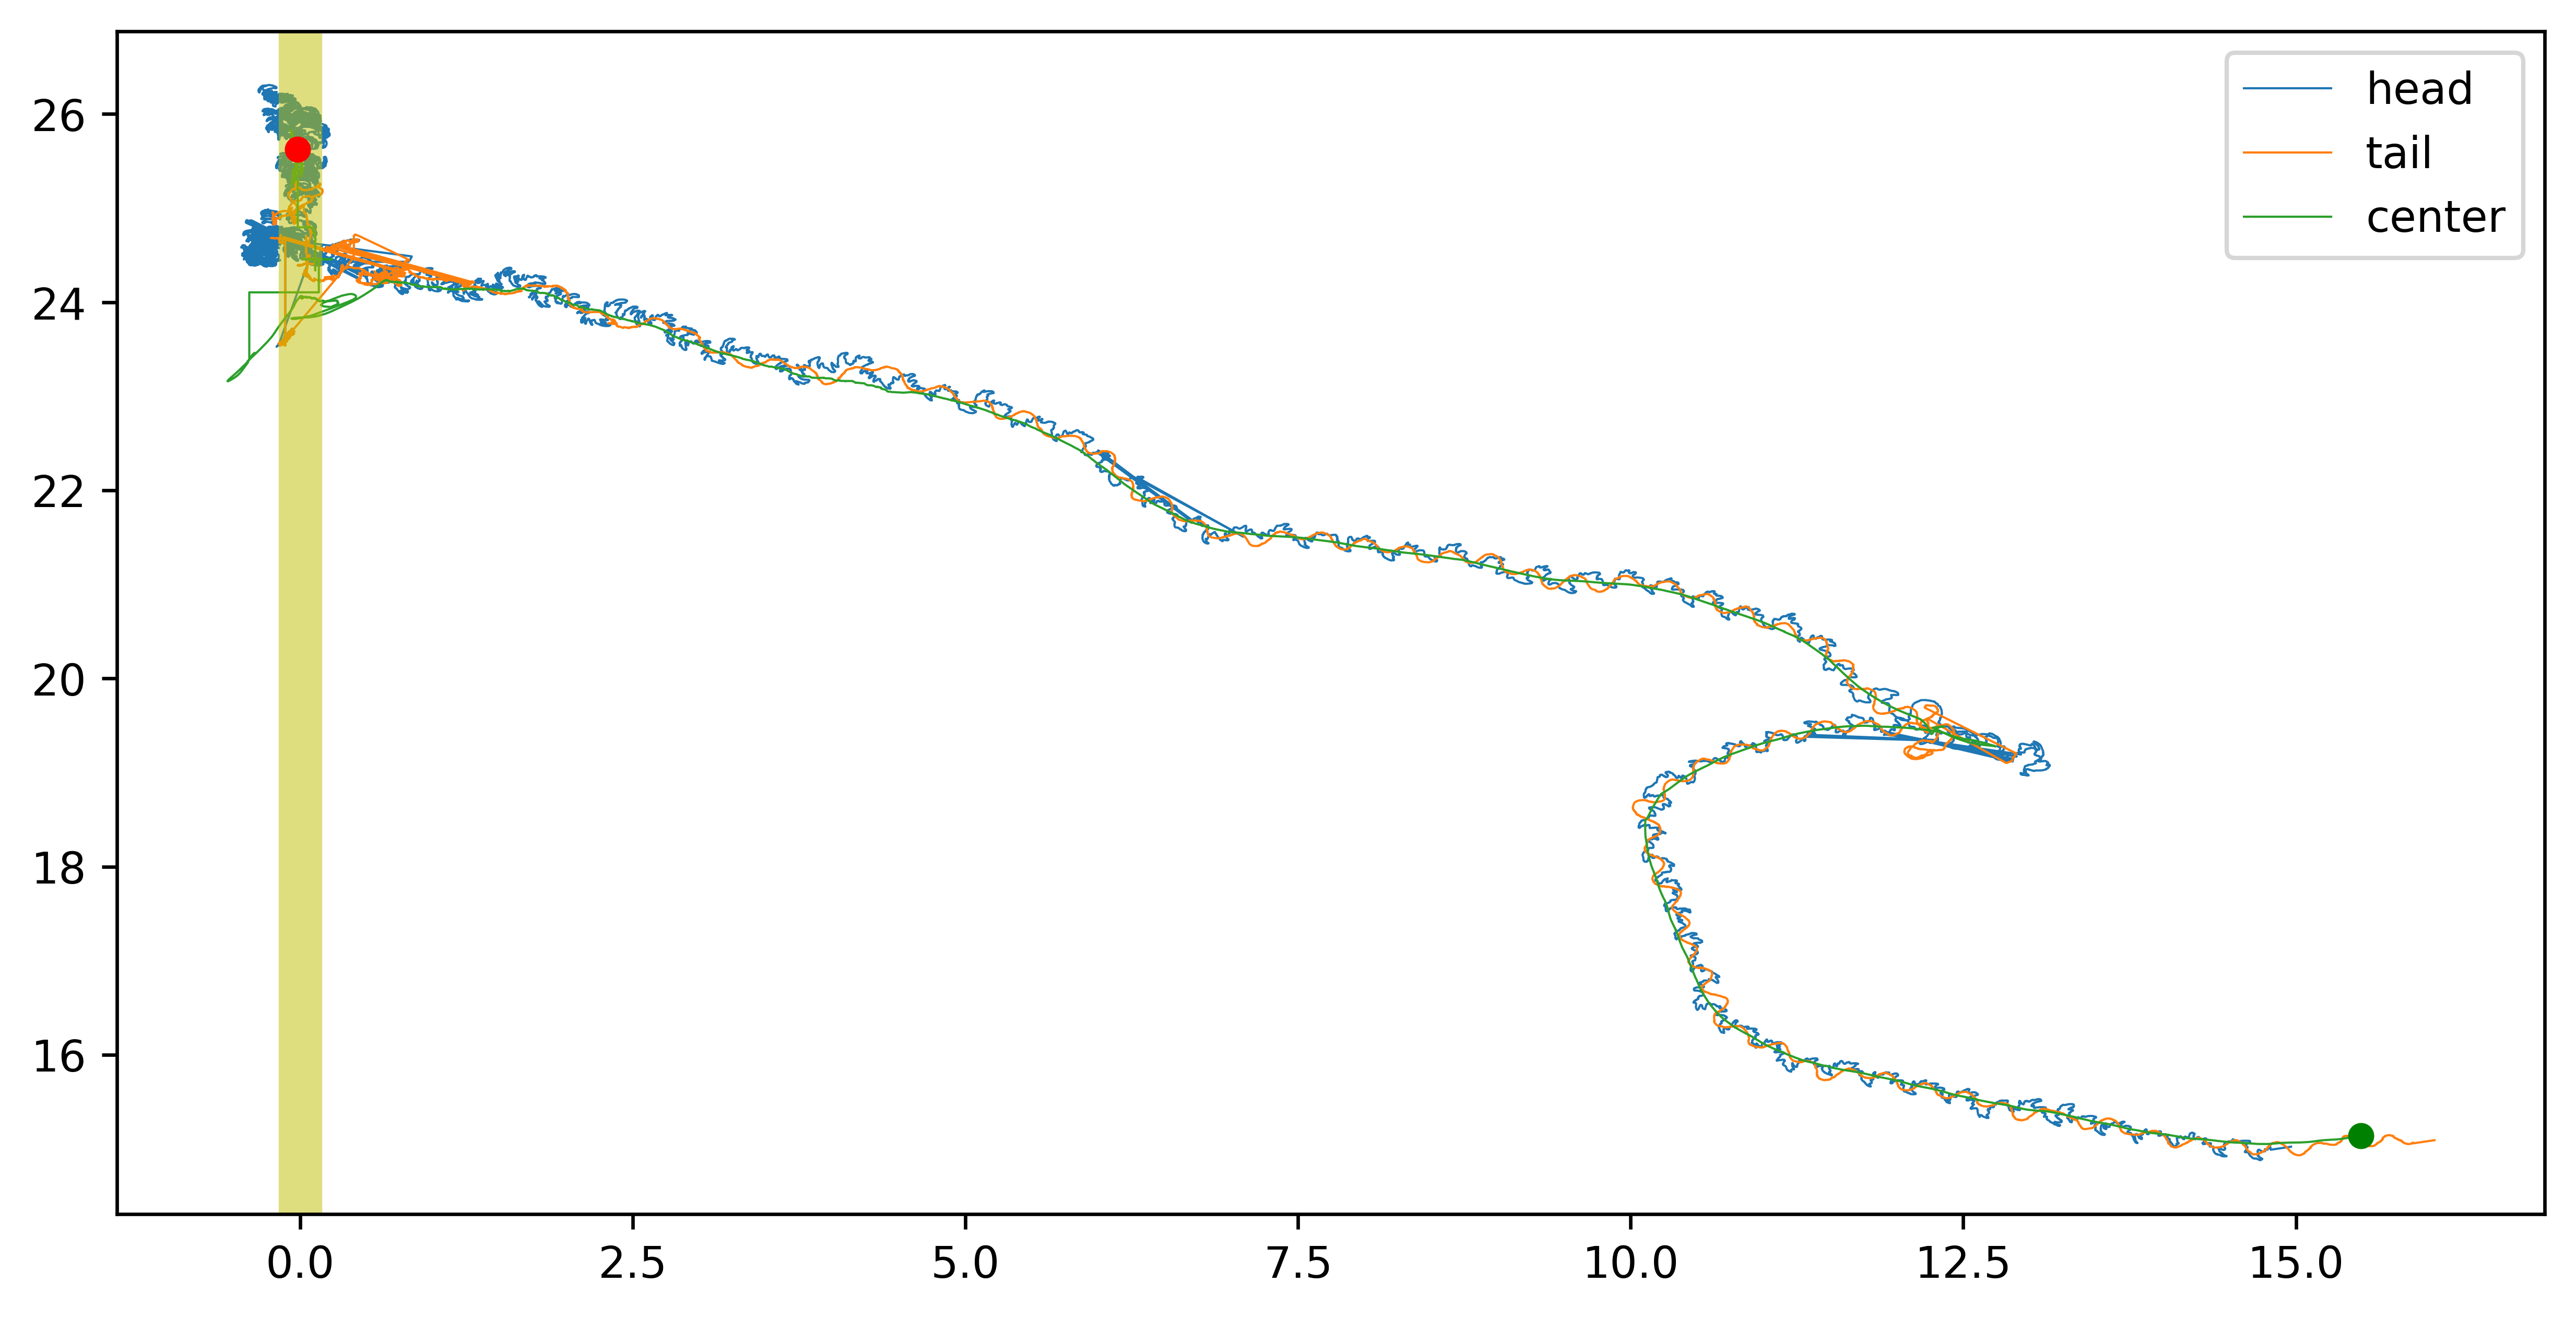

In [2]:
#these are csvs i created with the head_position script 
path='/groups/zimmer/Daniel_Mitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.csv'
df_head_tail_center_coords=pd.read_csv(path)
figsize_x=10
figsize_y=5
line_width=0.5
plot_tracks_center_head_tail(path,figsize_x,figsize_y,line_width)

#### choose part of a track

In [2]:
#here i pull out timeframes where the worm is either awy form food chemotaxing or in the food, in order to compare 
#it with fourier transformation

begin_x=0.3
end_x=2
begin_y=9.0
end_y=9.5
path='/groups/zimmer/Daniel_Mitic/data/2020-07-01_13-21-00_chemotaxisl_worm1.csv'
concentration_change=pd.read_csv(path, low_memory=False)

worm_pos=concentration_change[(concentration_change['absolute_x_Head'].between(begin_x,end_x))
    & (concentration_change['absolute_y_Head'].between(begin_y, end_y))]            
xmin=worm_pos['absolute_x_Head'].min()
xmax=worm_pos['absolute_x_Head'].max()
ymin=worm_pos['absolute_y_Head'].min()
ymax=worm_pos['absolute_y_Head'].max()

In [3]:
worm_pos

,Unnamed: 0,absolute_x_Head,absolute_y_Head,absolute_x_Tail,absolute_y_Tail,x_center,y_center,concentration_Head,concentration_Tail,concentration_Center,concentration_change_Head,concentration_change_Tail,concentration_change_Center,seconds
111656,111656,0.767225,9.000290,1.000534,8.012921,0.7666,8.3745,0.833394,0.788463,0.833517,0.000034,0.000037,0.000040,668.598802
111657,111657,0.768874,9.000721,1.000130,8.013421,0.7664,8.3750,0.833067,0.788538,0.833557,-0.000326,0.000076,0.000040,668.604790
111658,111658,0.768812,9.001057,1.000022,8.013994,0.7663,8.3754,0.833079,0.788559,0.833577,0.000012,0.000020,0.000020,668.610778
111659,111659,0.768915,9.001386,0.999257,8.014494,0.7661,8.3759,0.833059,0.788702,0.833616,-0.000020,0.000143,0.000040,668.616766
111660,111660,0.768948,9.001986,0.998954,8.015094,0.7659,8.3765,0.833053,0.788759,0.833656,-0.000007,0.000057,0.000040,668.622754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112986,112986,0.727254,9.497515,0.663337,8.577540,0.8160,9.0271,0.841344,0.854216,0.823794,0.000289,-0.000151,-0.000039,676.562874
112987,112987,0.726823,9.498015,0.663494,8.578010,0.8160,9.0276,0.841430,0.854184,0.823794,0.000086,-0.000032,0.000000,676.568862
112988,112988,0.726119,9.498860,0.663600,8.578710,0.8161,9.0283,0.841571,0.854163,0.823774,0.000141,-0.000021,-0.000020,676.574850
112989,112989,0.725517,9.499215,0.664040,8.579113,0.8162,9.0288,0.841691,0.854073,0.823754,0.000120,-0.000089,-0.000020,676.580838


In [4]:
#index min and max is equal to the time window in which the worm was in the specifies section of the track
print(worm_pos.index.min())
print(worm_pos.index.max())

111656
112990


        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


KeyError: 'x_head_corrected'

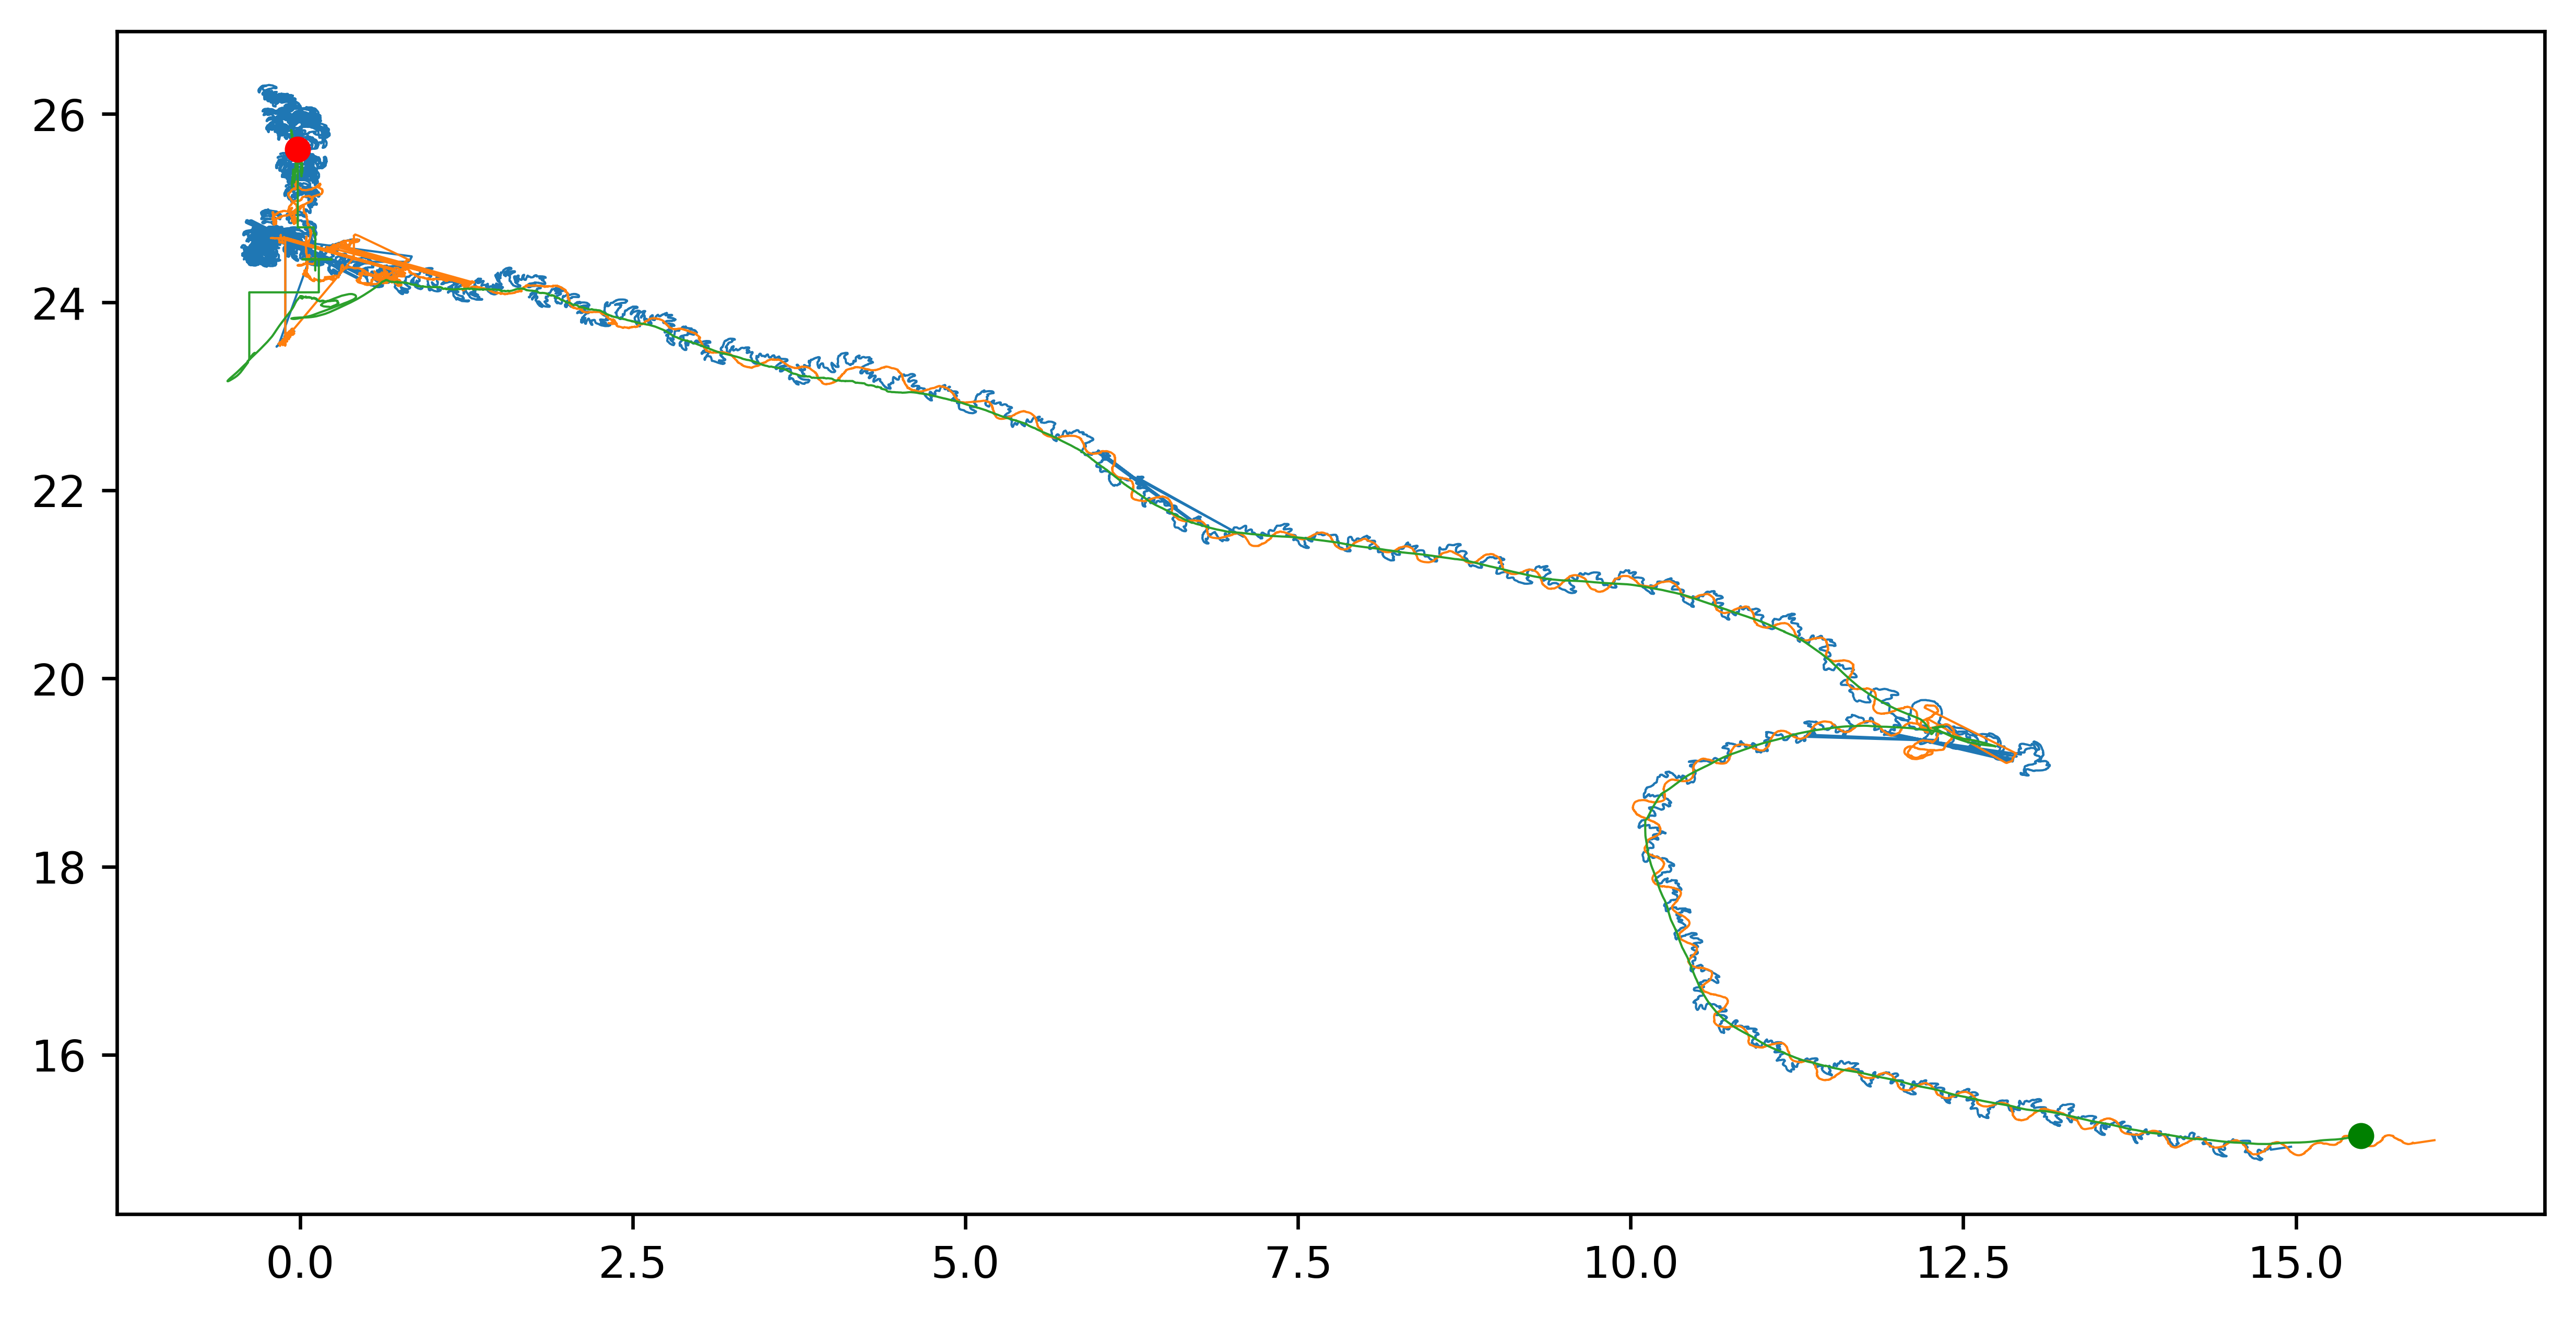

In [6]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
x_head_corrected=df_head_tail_center_coords['x_head_corrected']
y_head_corrected=df_head_tail_center_coords['y_head_corrected']
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected']
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']
y_center_pos=df_head_tail_center_coords['y_center']
print(df_head_tail_center_coords.tail(1))
fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(x_head_corrected,y_head_corrected,label="head",linewidth=line_width)
ax3.plot(x_tail_corrected,y_tail_corrected,label="tail",linewidth=line_width)
ax3.plot(x_center_pos,y_center_pos,label="center",linewidth=line_width)
ax3.plot(df_head_tail_center_coords['x_center'][0],df_head_tail_center_coords['y_center'][0], 'go', markersize=5)
ax3.plot(df_head_tail_center_coords['x_center'].tail(1),df_head_tail_center_coords['y_center'].tail(1), 'ro', markersize=5)
xposition = [worm_pos['x_head_corrected'].min(), worm_pos['x_head_corrected'].max()]

rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1, edgecolor='r', facecolor='none')
ax3.add_patch(rect)
ax3.legend()

## applying the fourier transform to choosen part of the track

####  loading curvature data

In [5]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_13-21-00_chemotaxisl_worm1_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]



#### average over a number of segments

In [6]:
win=1
Kt_avg=segment_averaging(K,win)

number of rows and columns:(100, 197999)


#### define the section of the track to do the fourier transform
(determined above by looking at the track)

In [7]:
start_frame=worm_pos.index.min()
end_frame=worm_pos.index.max()
fps=167.0 #frames per second
Kt_avg=section_to_fourier_transform(Kt_avg,start_frame,end_frame,fps)

lenght of recording:7.9880239520958085 secs
shape:(1334, 100)


In [8]:
start_frame=worm_pos.index.min()
end_frame=worm_pos.index.max()
print(start_frame)
print(end_frame)

111656
112990


In [9]:
len(K)

197999

In [10]:
#switch rows and columns for the fourier function
Kt_avg=Kt_avg.T

In [11]:
Kt_avg.shape

(100, 1334)

In [12]:
def fourier_plot(x_axis,y_axis,start_frame,end_frame,start_freq,end_freq,win,fps,segment,idx,save):
    """
    plots the output of fourier_transform
    Parameters:
    -----------------
    x_ft: x axis of fourier transform
    y_ft: y axis of fourier transform
    start_frame
    end_frame
    start_freq, end_freq, frequncy range to be displayed
    win: window over which the segments where averaged
    fps:frames per second
    save: 1 for saving
    """
    plt.rcParams.update({'figure.max_open_warning': 0})
    plt.rcParams.update({'font.size': 16})
    y=segment
    x=np.arange(0, y.shape[0]/fps,1/fps)
    
    #plotting:
    #oscilations
    plt.figure(figsize=(20,3))
    plt.subplot(1,2,1)
    plt.plot(x,y)
    #plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
    #if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
    #plt.title('Segment '+(str(idx)))
    plt.xlabel('Time (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    plt.ylim(-0.04,0.04)
    
    #Frequency
    plt.subplot(1,2,2)
    plt.plot(x_axis,y_axis)
    plt.xticks(np.arange(start_freq, end_freq, step=1))
    plt.xlim(start_freq,end_freq)
    #plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
    #if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
    #plt.title('Segment '+(str(idx)))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')
    if save!=0:    
        plt.savefig(str(idx)+'.png')
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.3)

In [8]:
for idx,segment in enumerate(Kt_avg):
    print(len(segment))
    y=segment
    x=np.arange(0, y[start_frame:end_frame].shape[0]/fps,1/fps)
    y=y[start_frame:end_frame]
    print(y)
    break
    

NameError: name 'Kt_avg' is not defined

#### fourier transform and plot

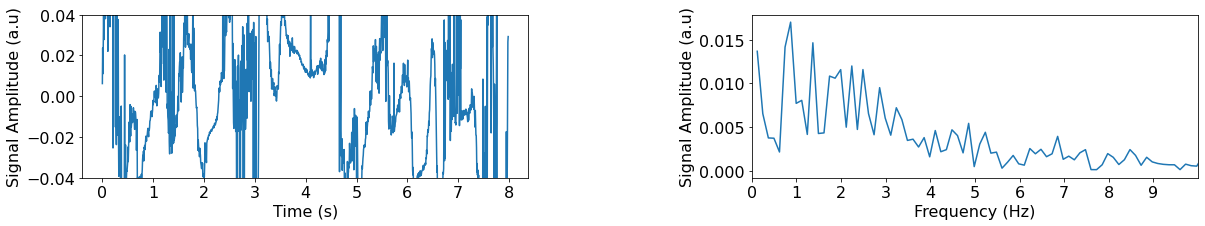

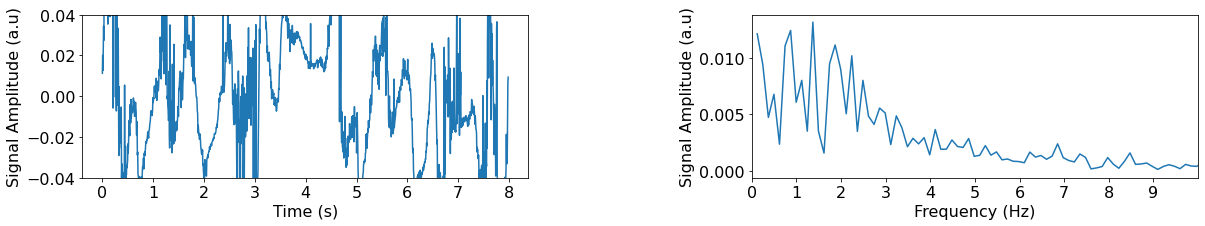

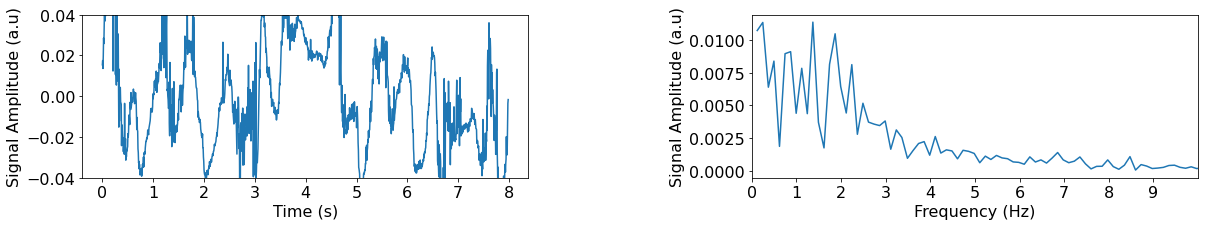

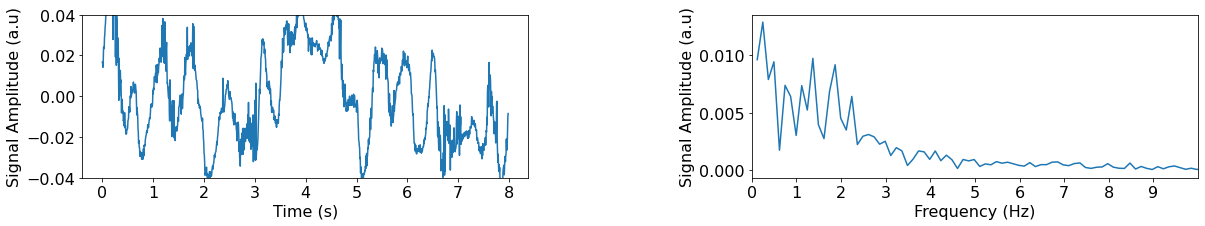

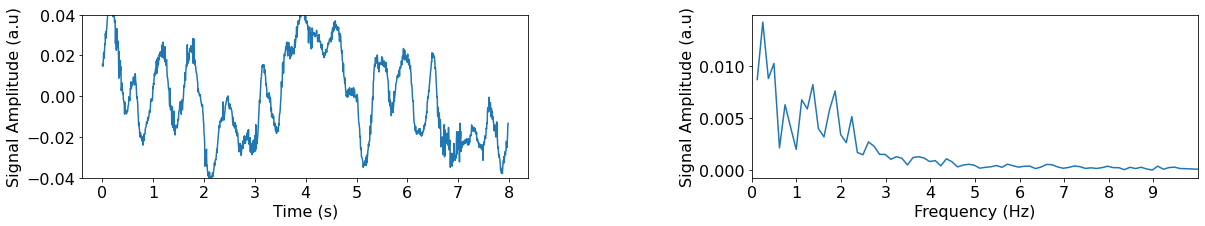

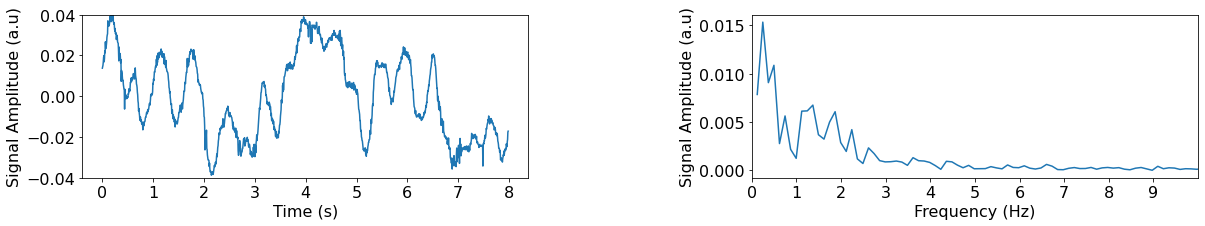

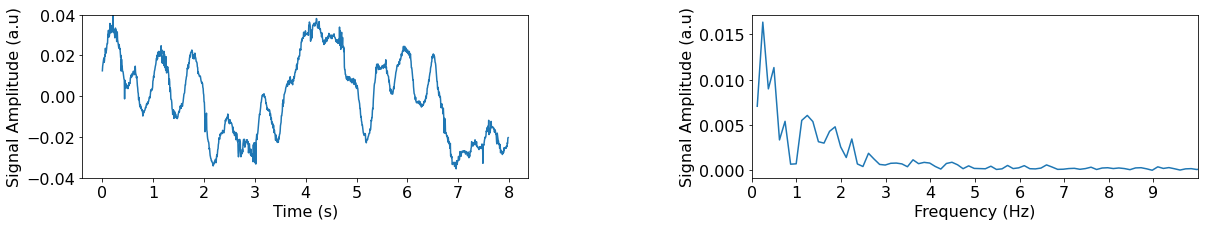

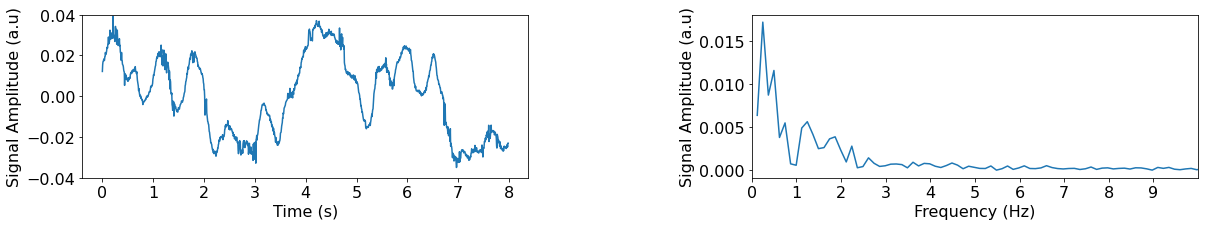

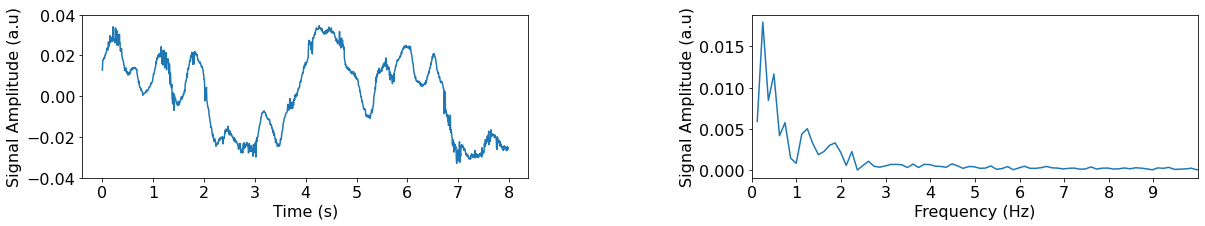

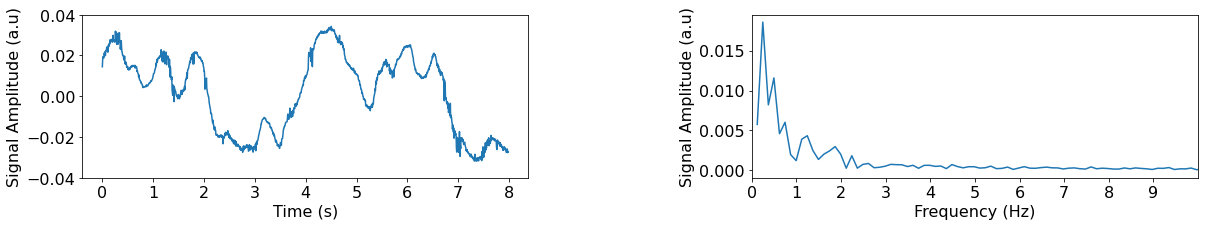

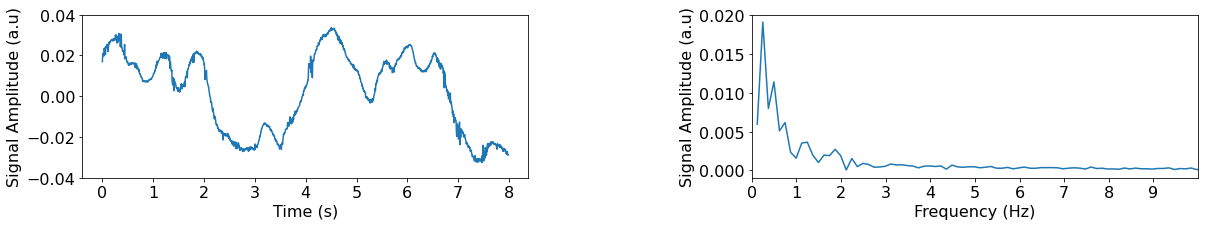

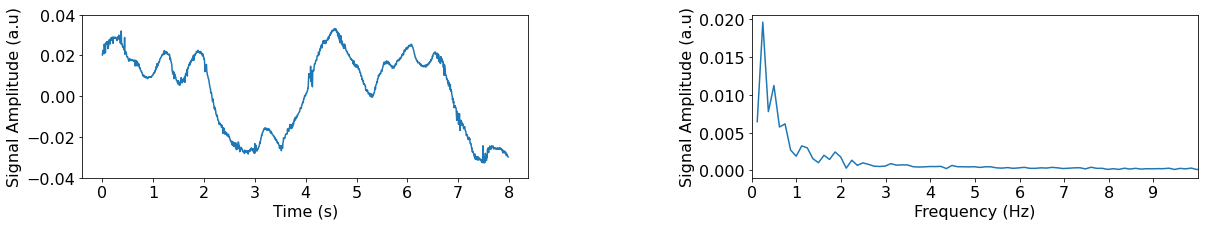

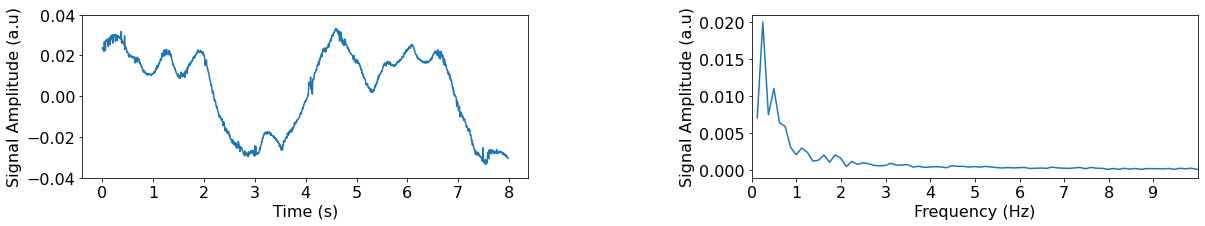

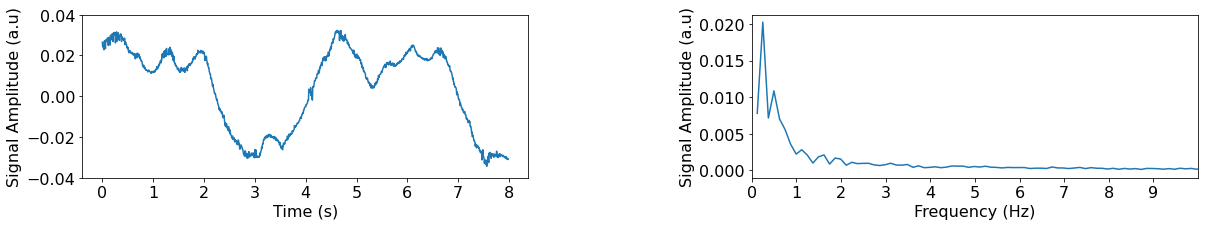

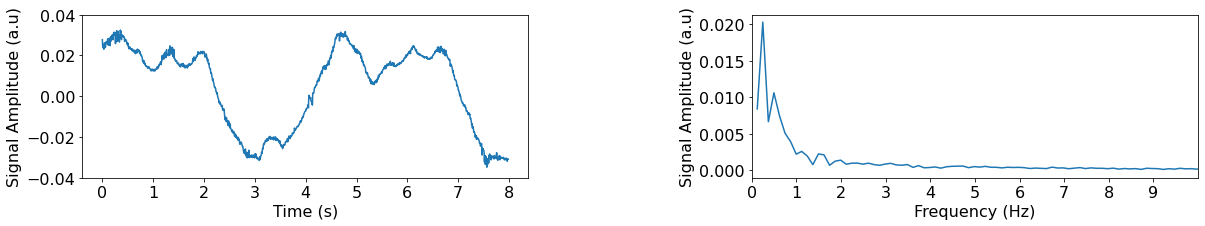

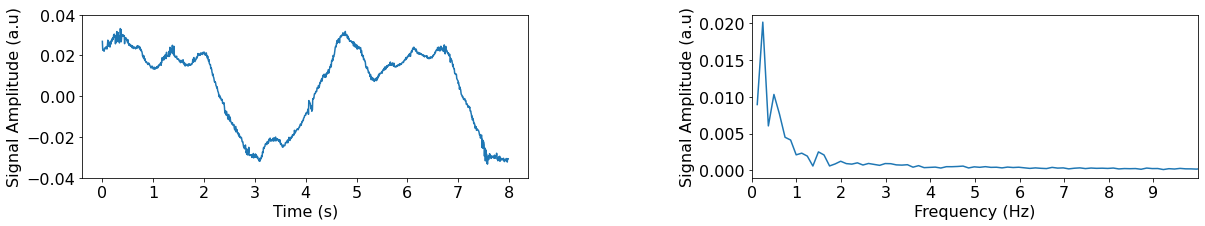

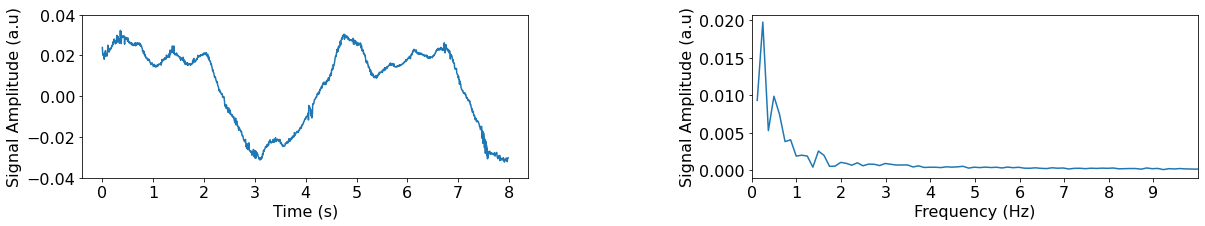

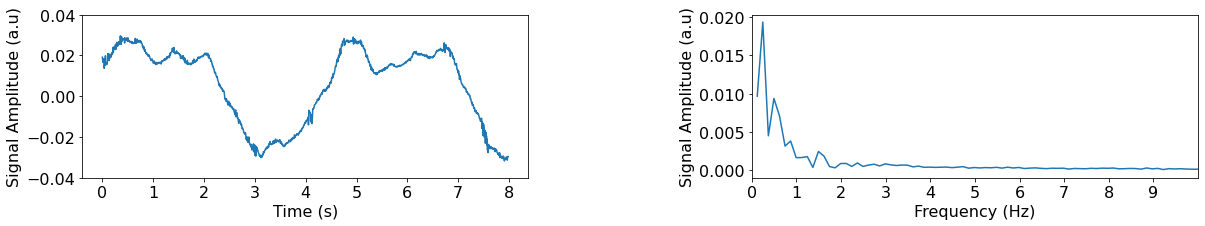

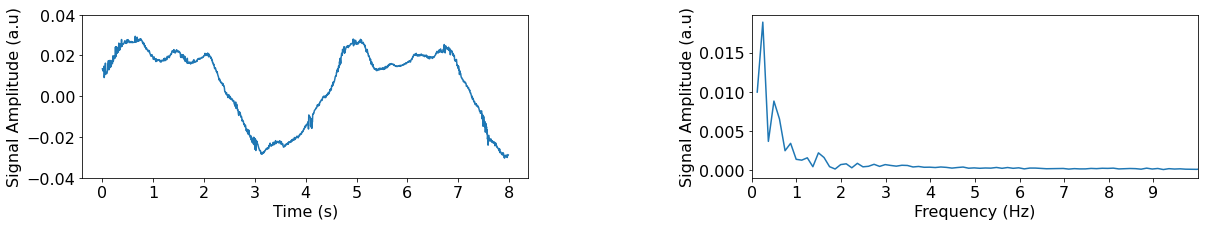

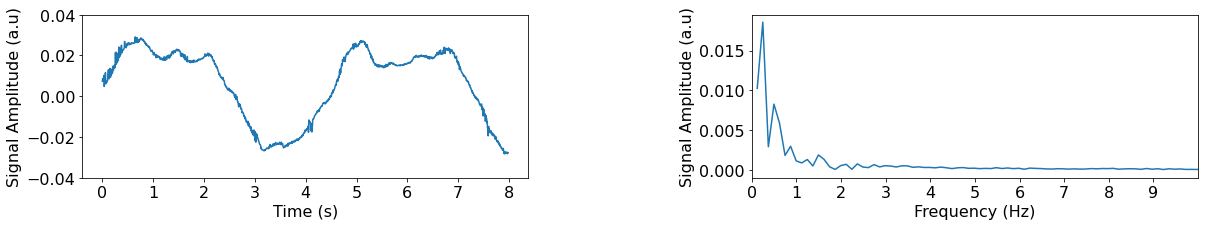

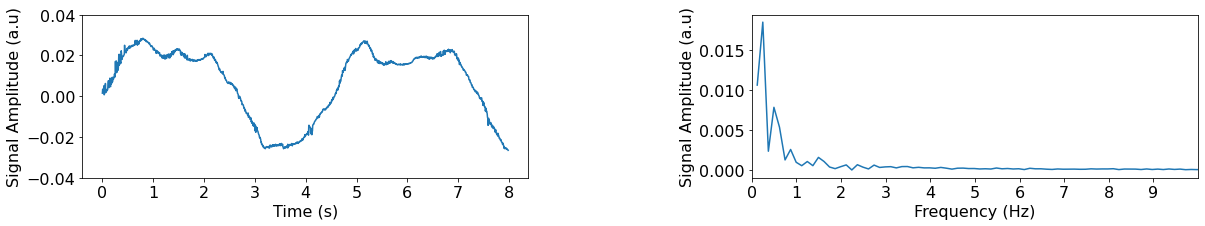

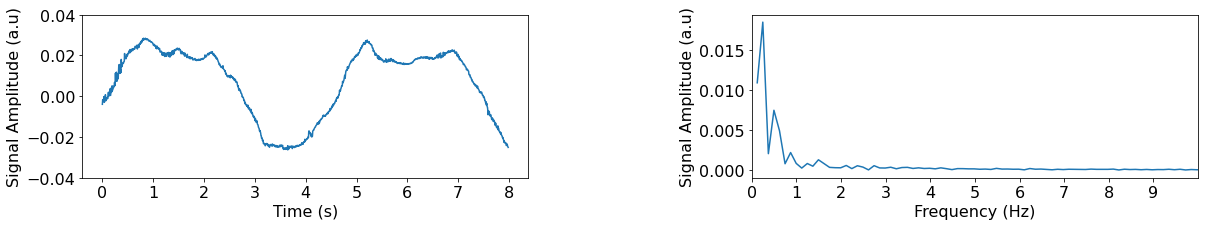

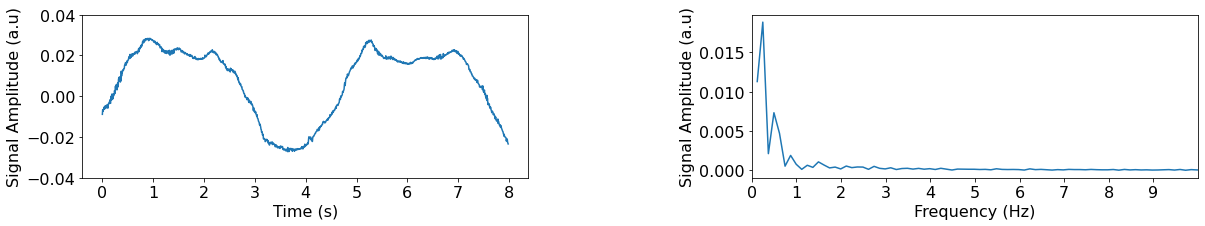

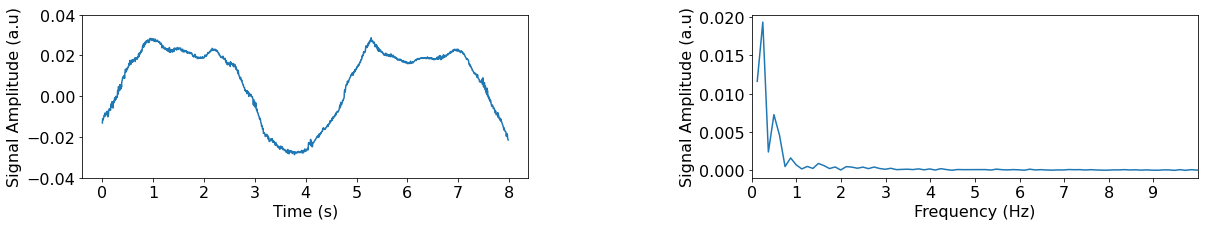

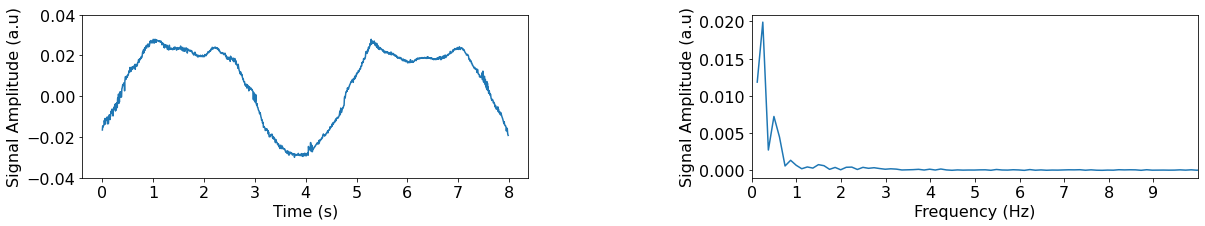

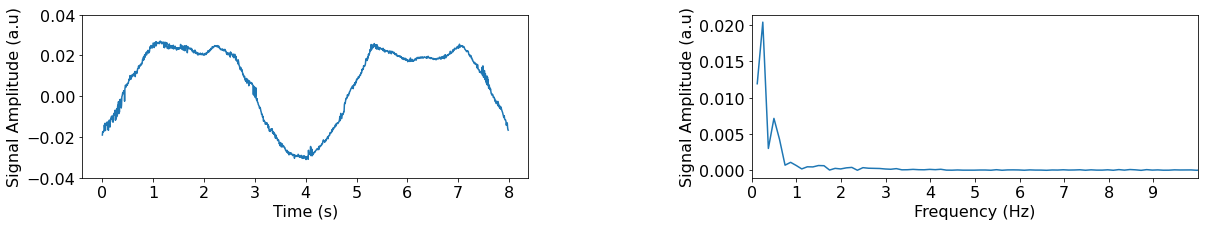

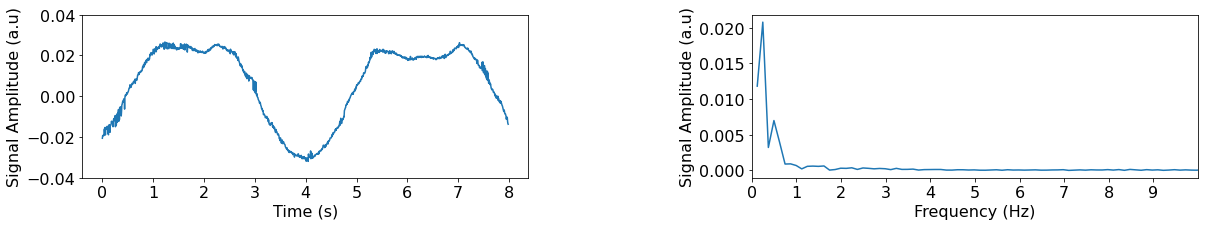

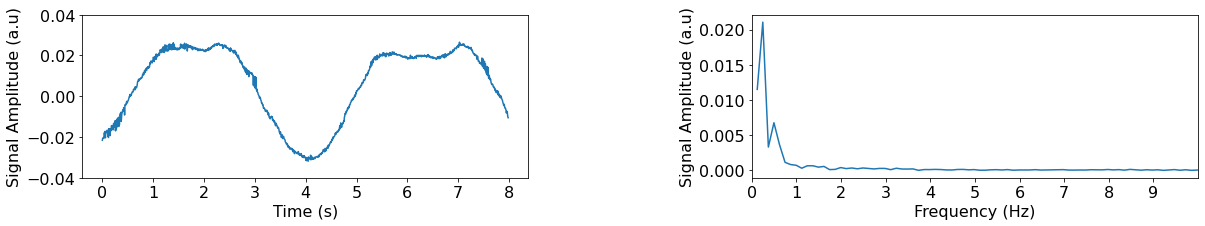

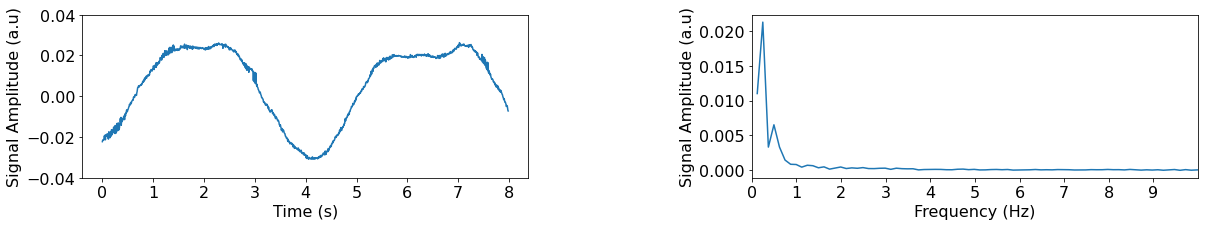

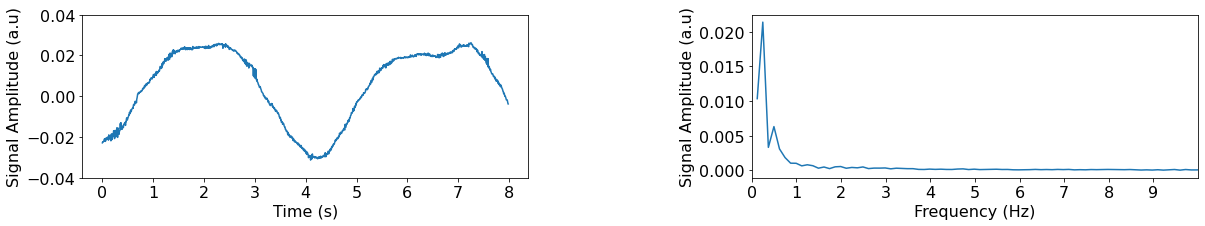

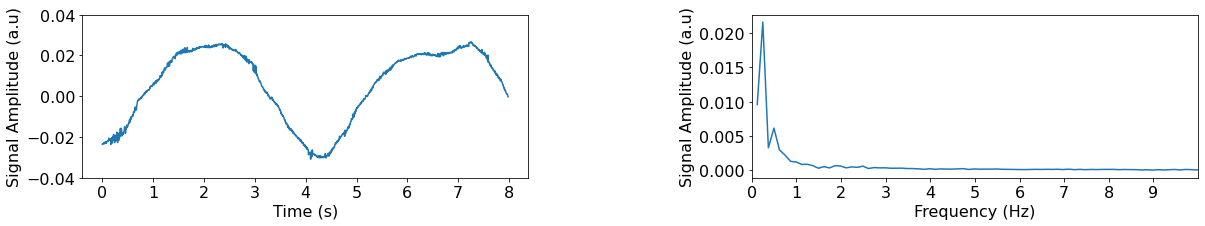

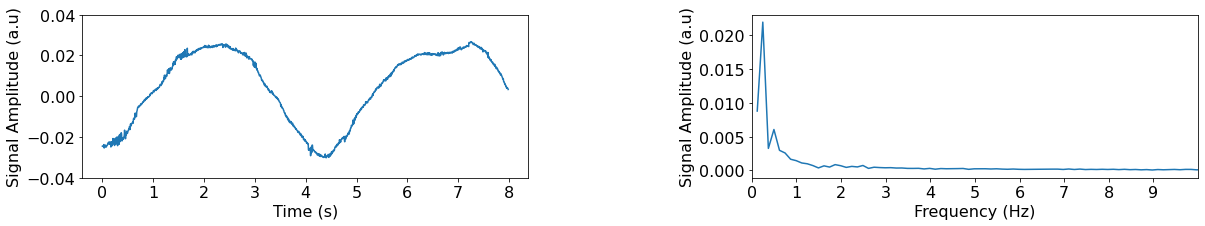

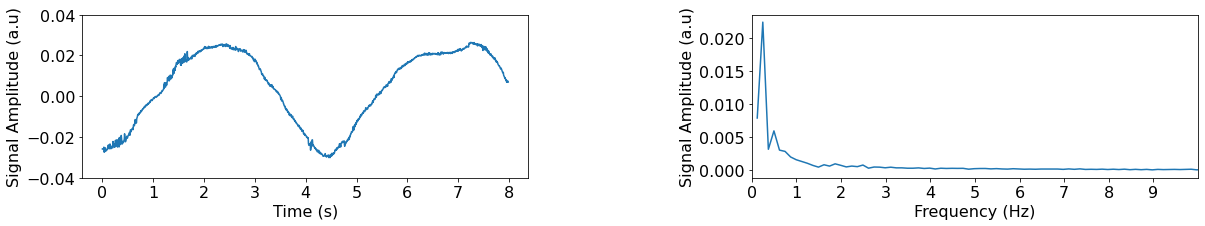

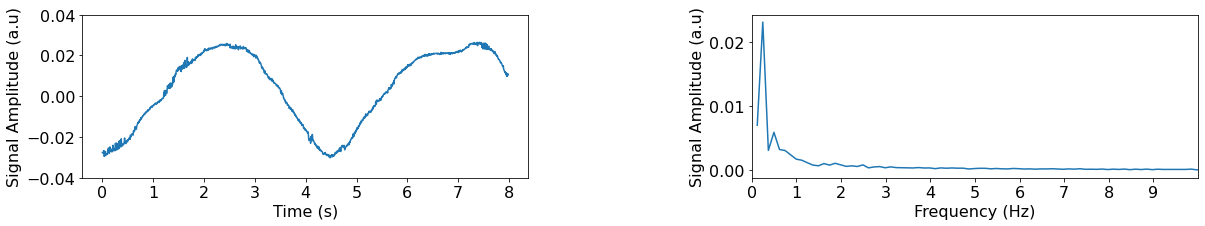

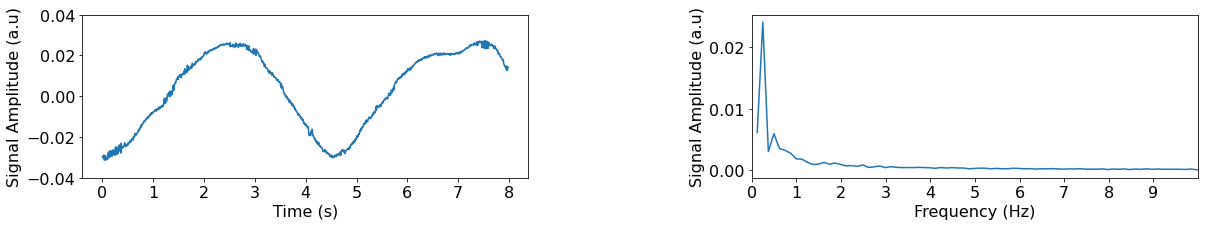

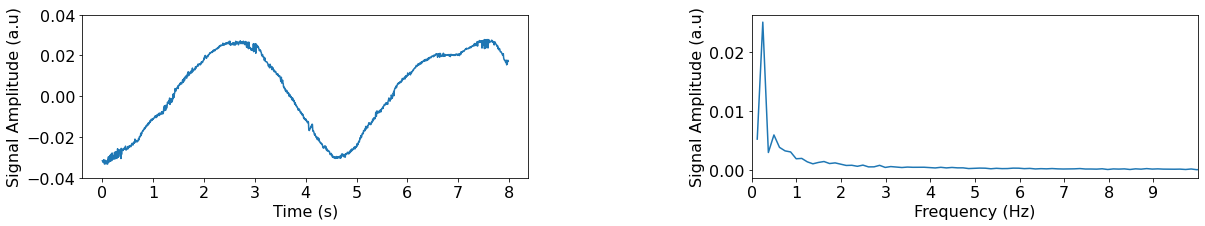

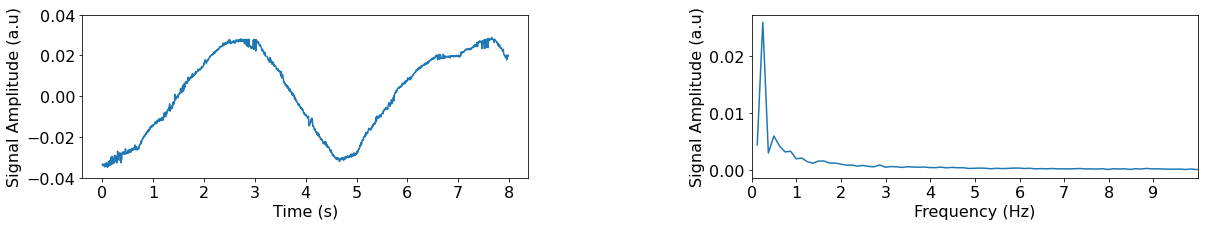

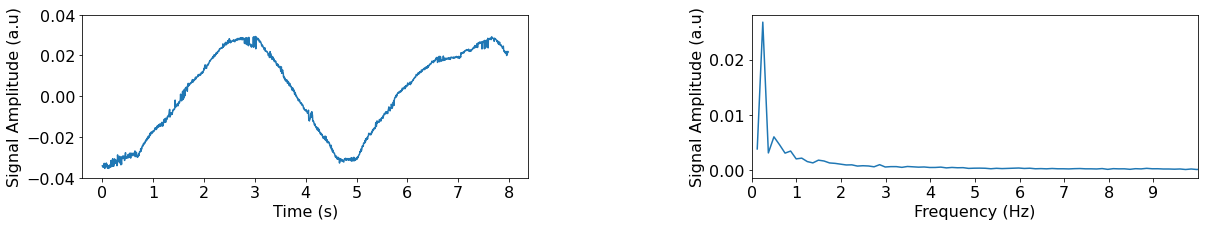

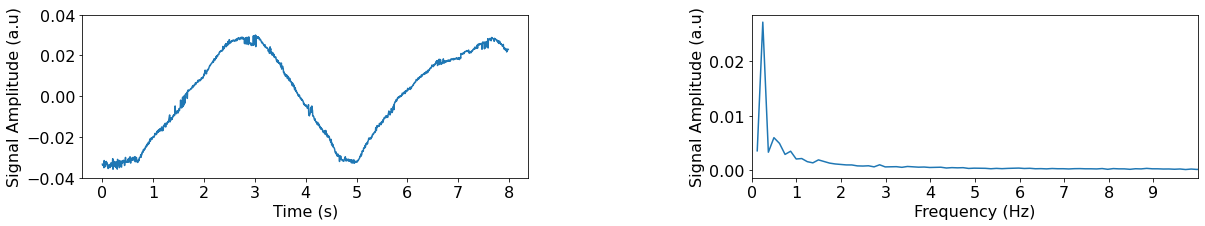

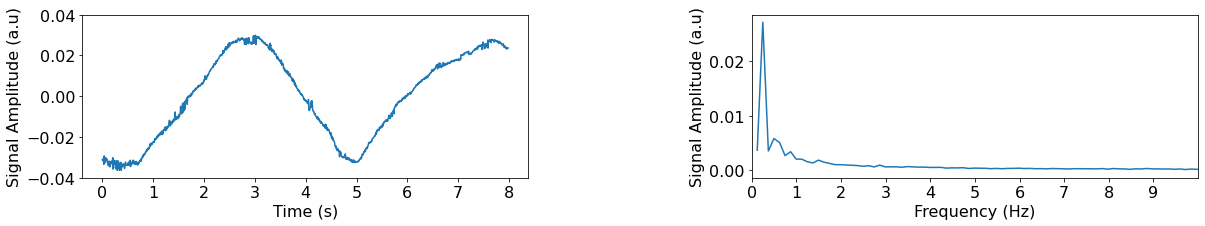

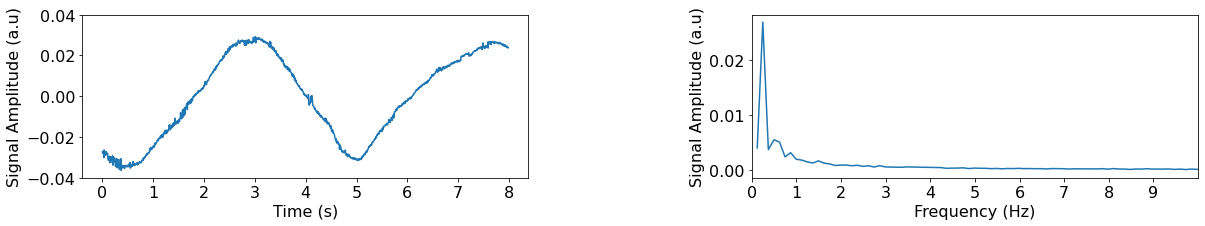

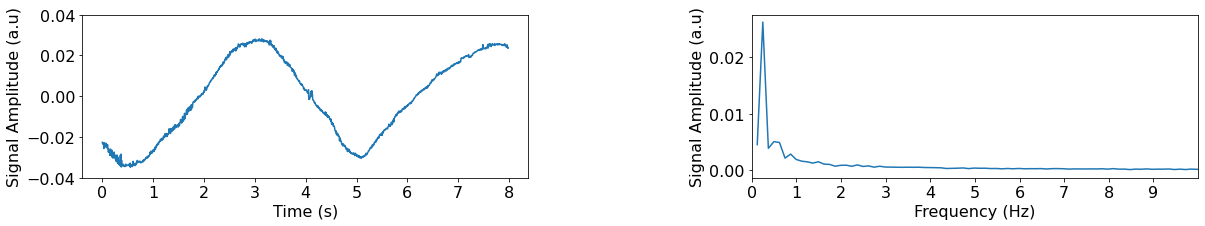

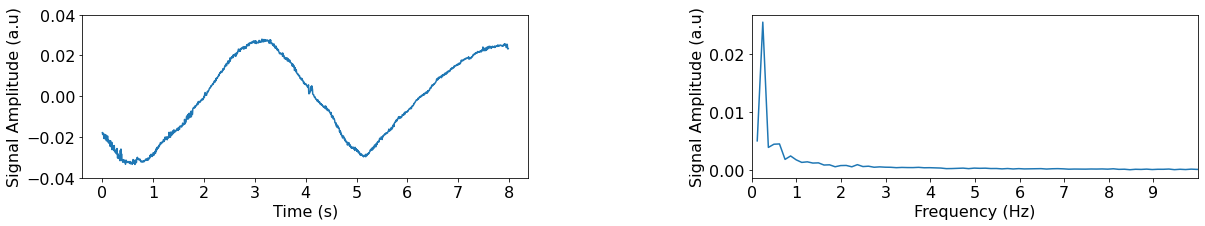

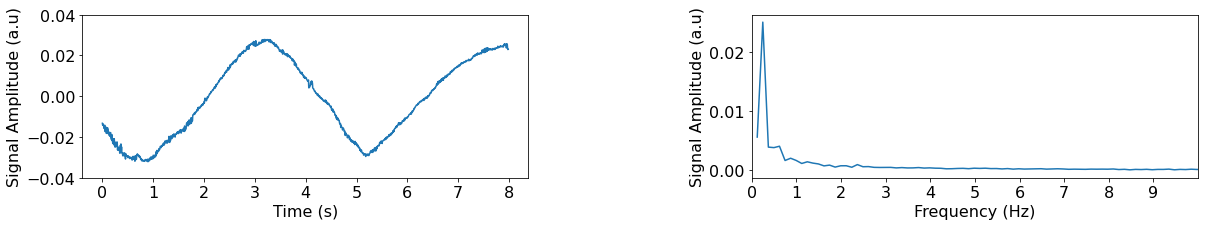

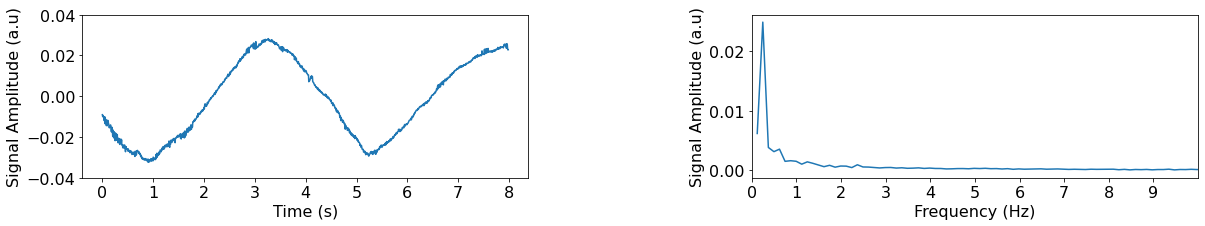

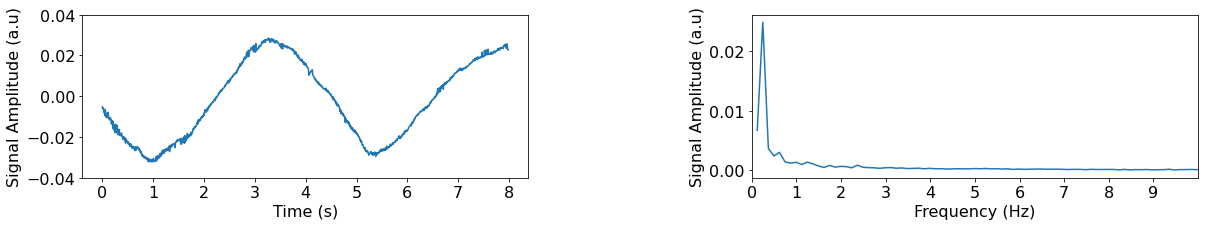

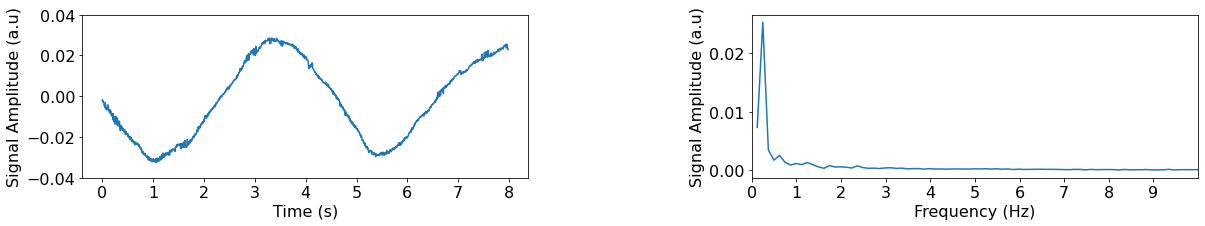

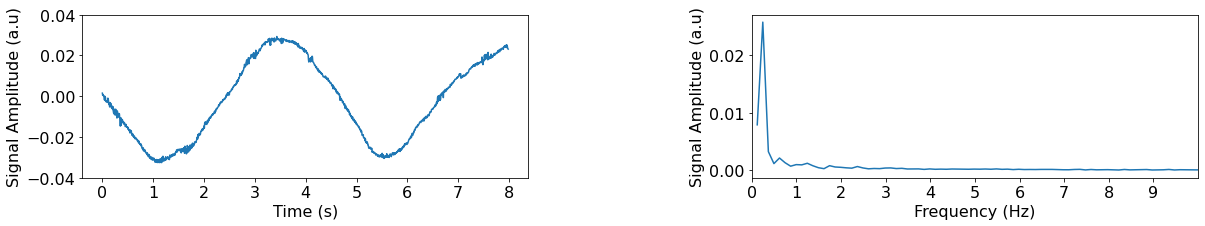

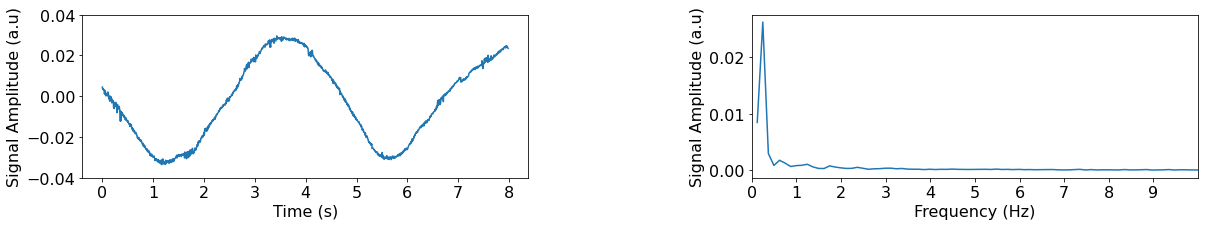

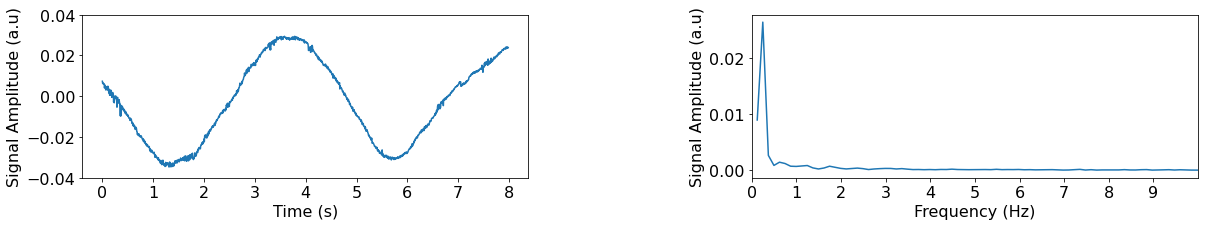

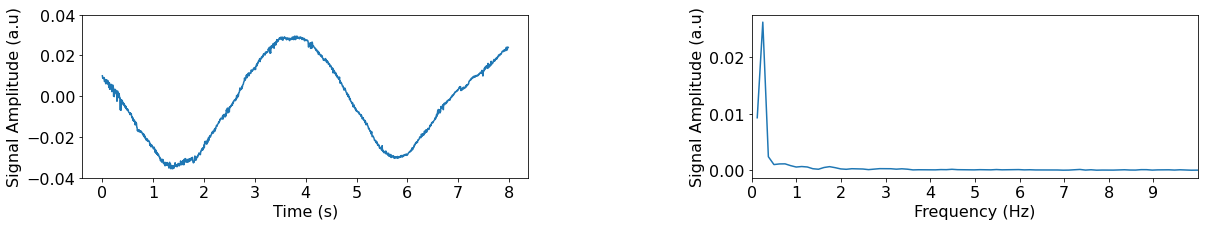

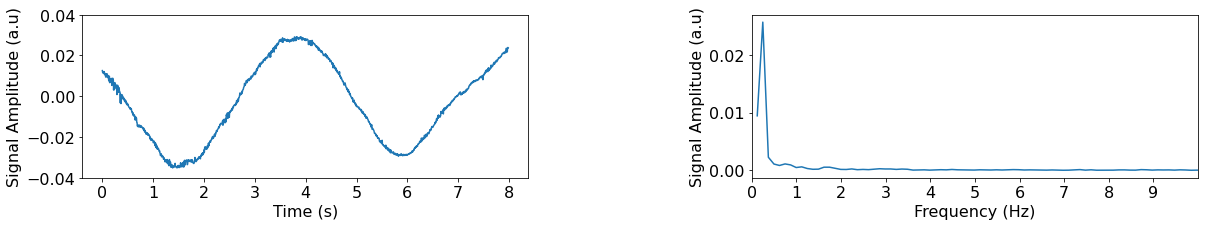

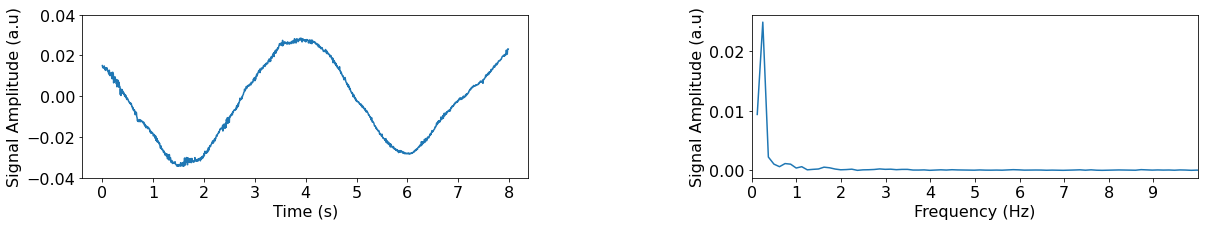

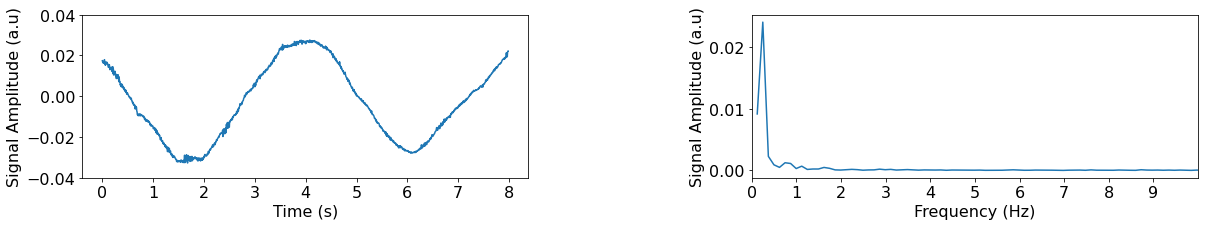

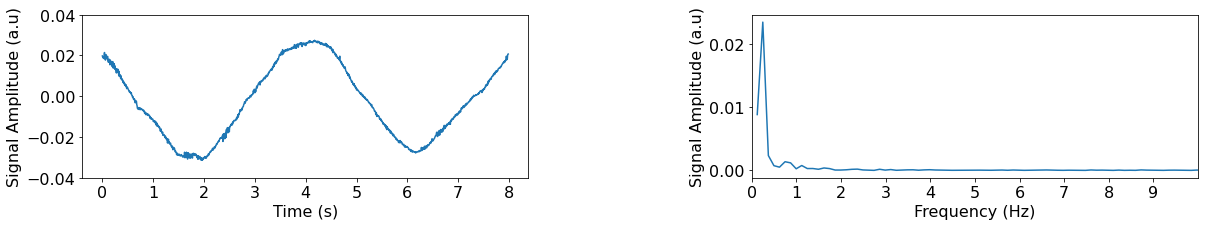

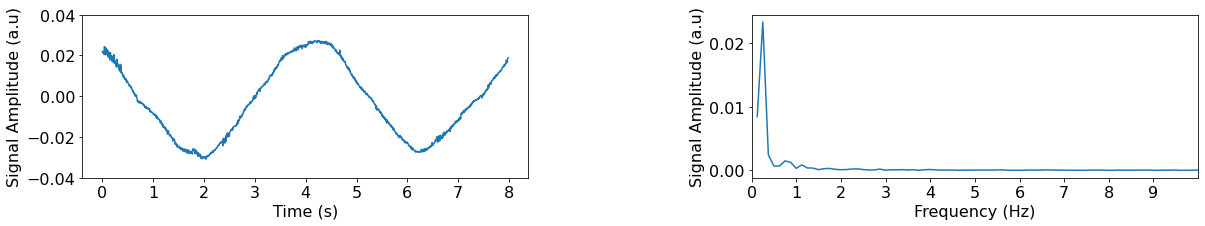

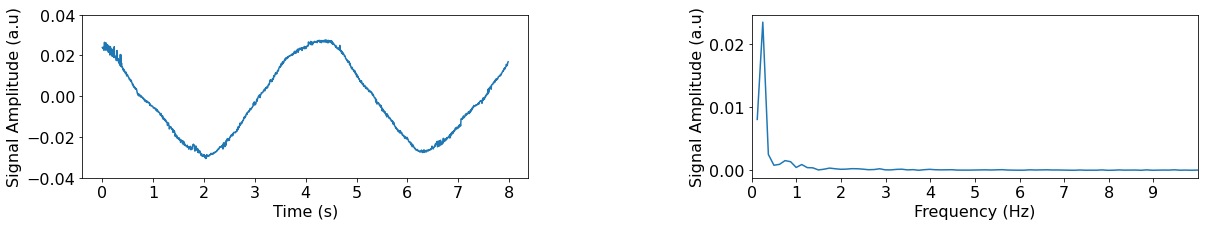

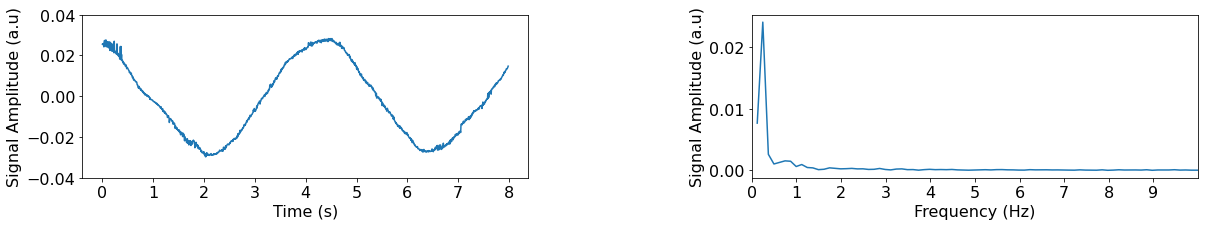

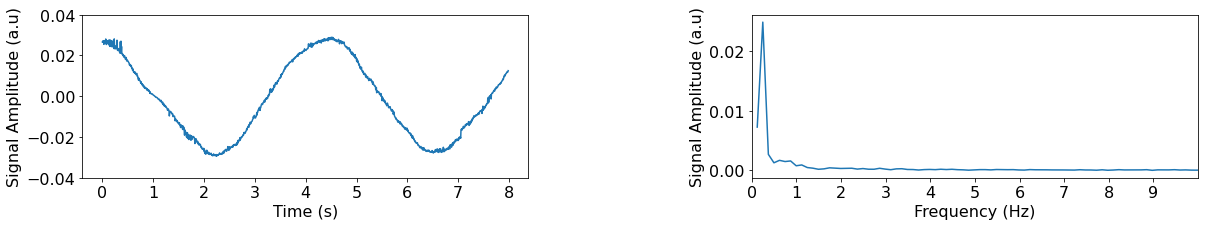

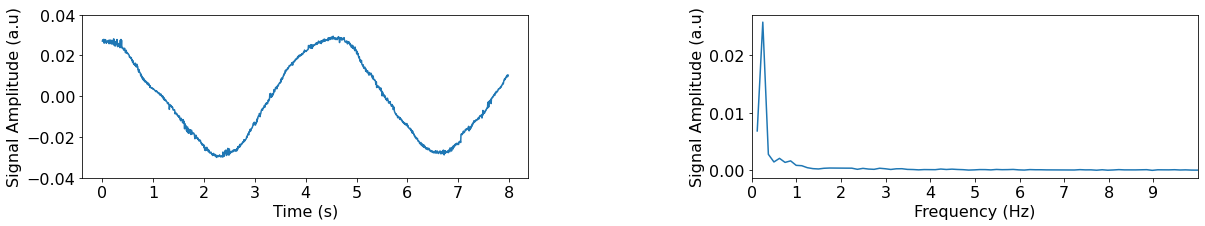

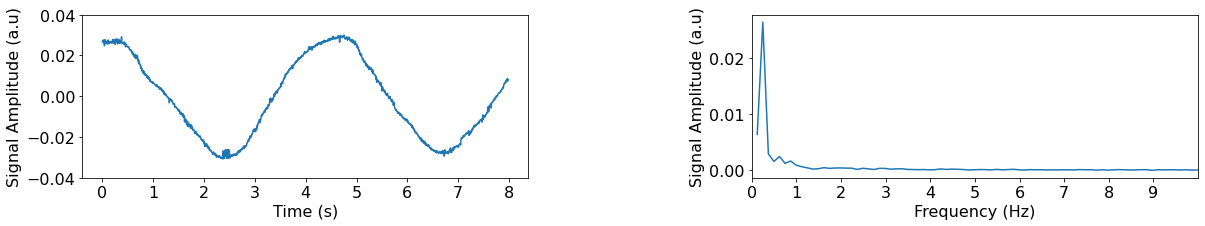

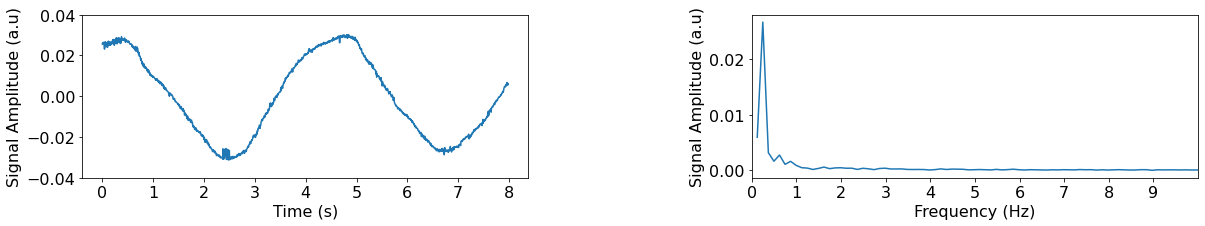

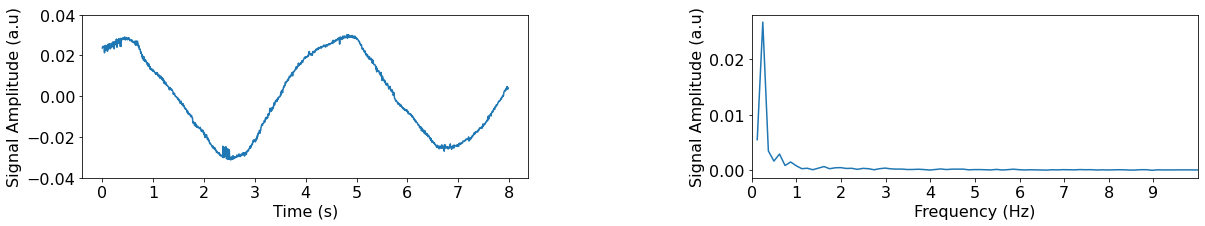

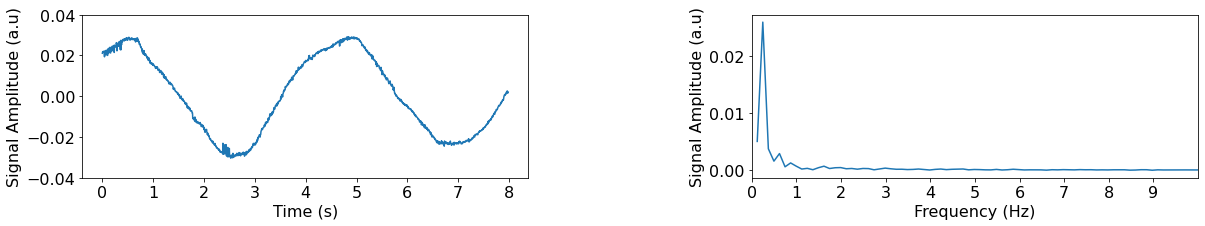

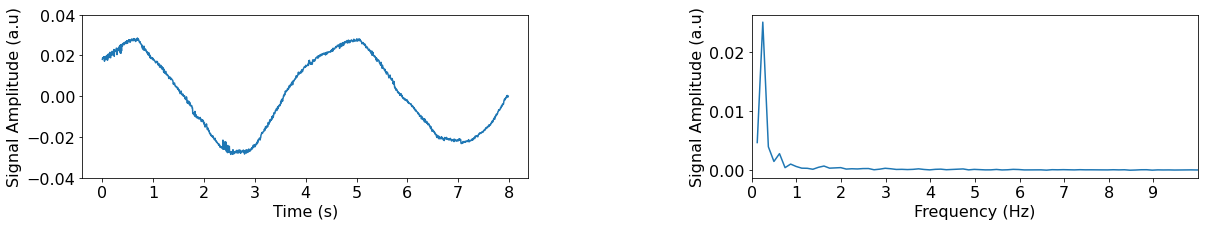

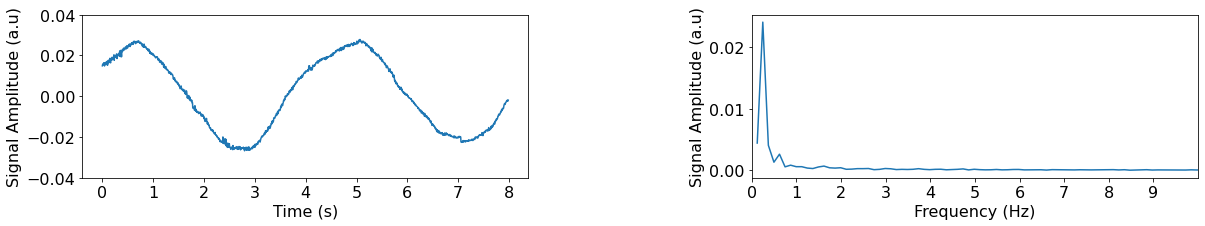

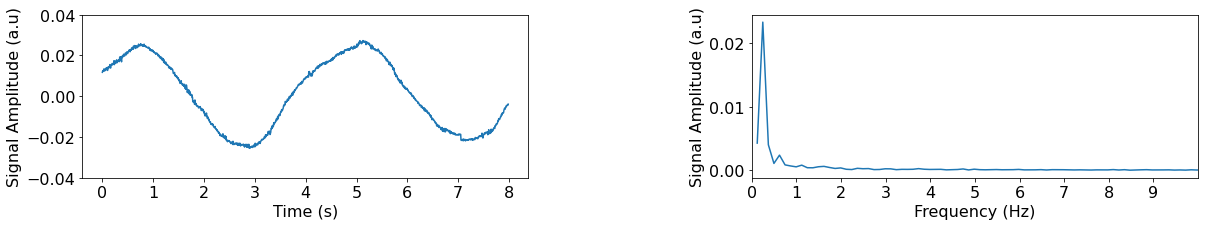

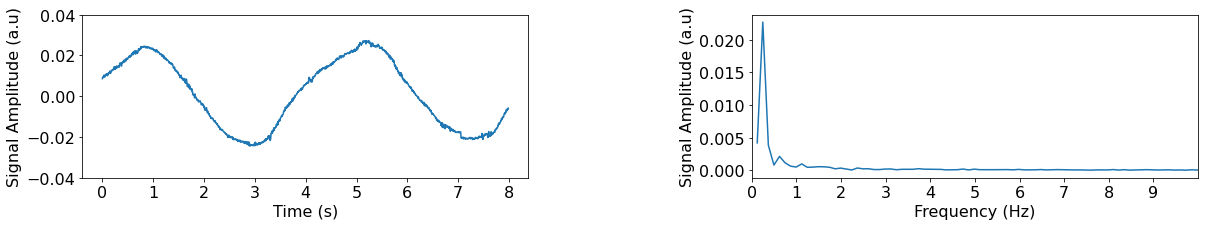

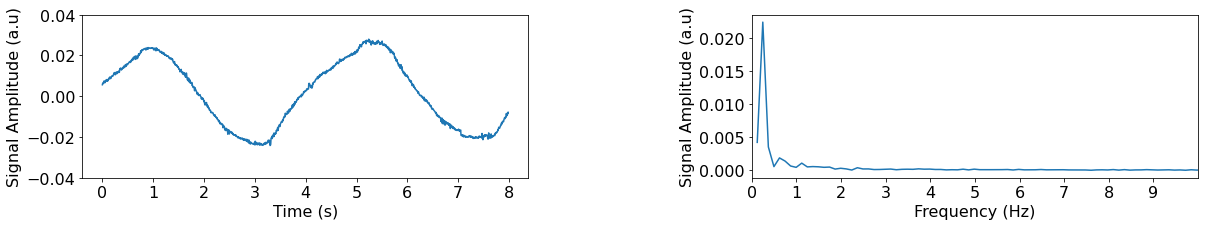

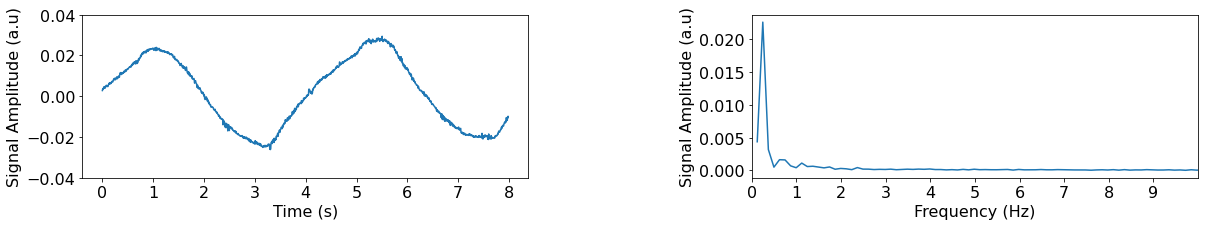

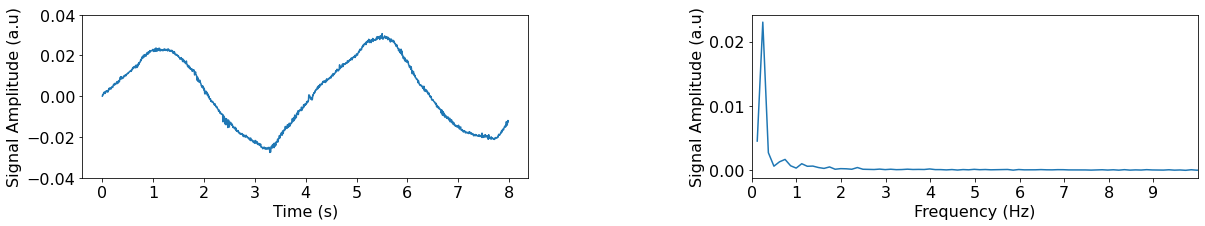

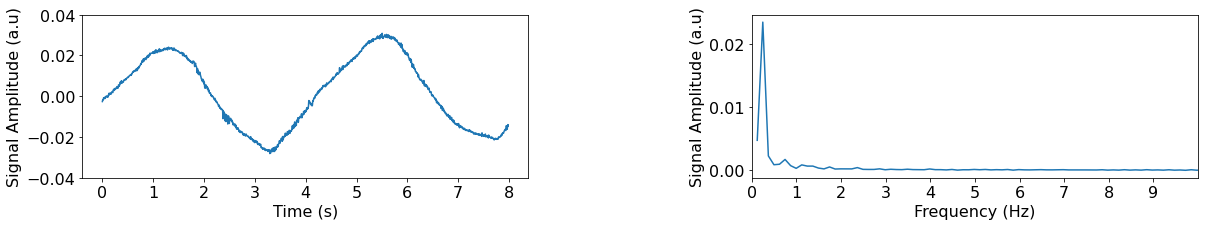

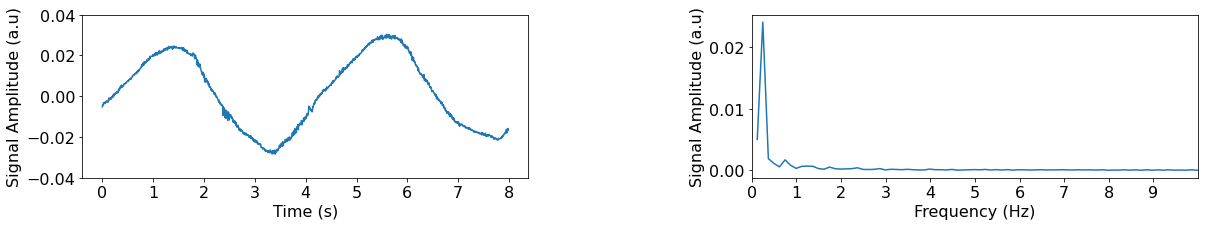

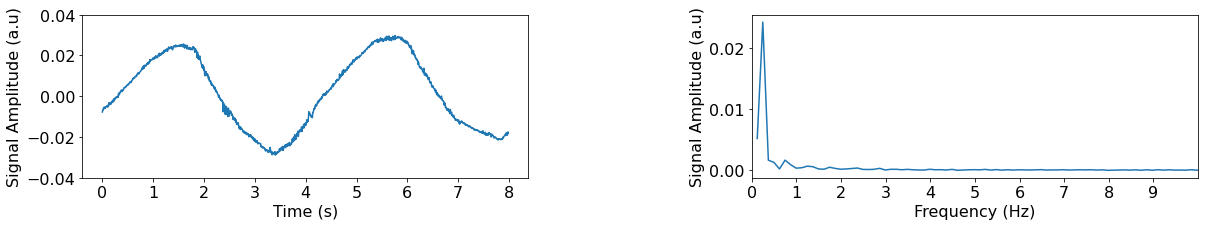

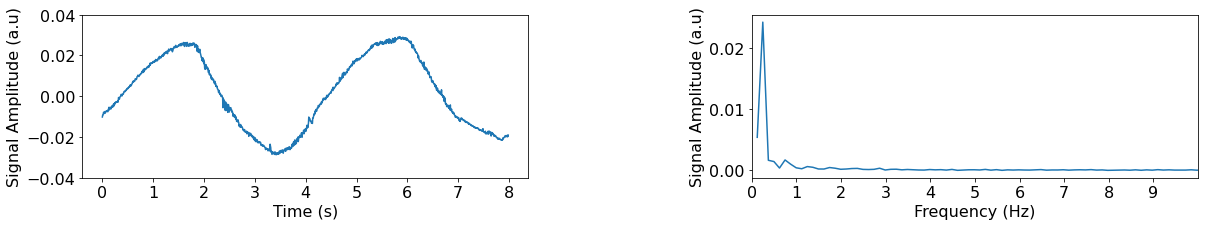

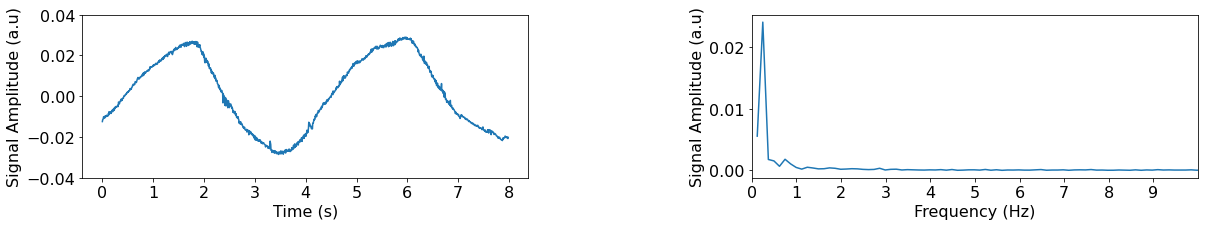

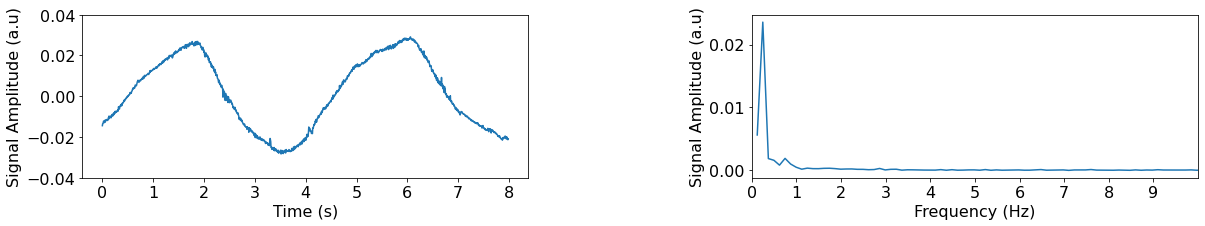

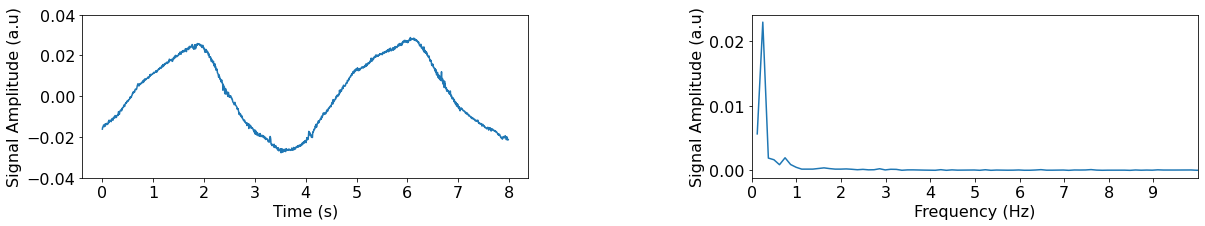

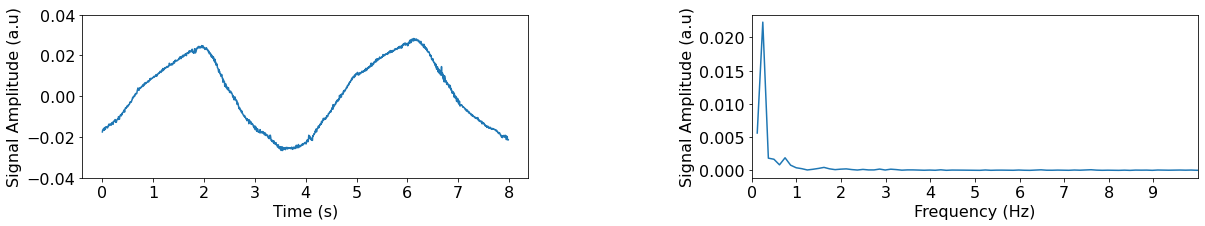

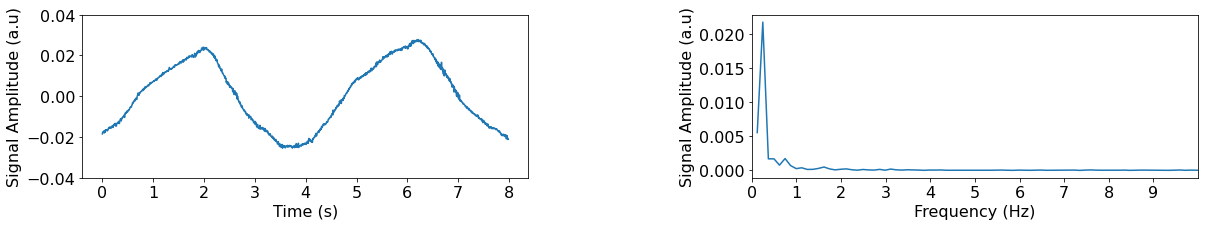

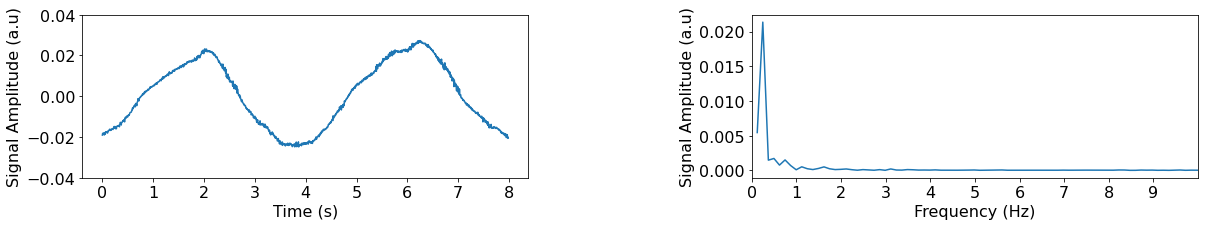

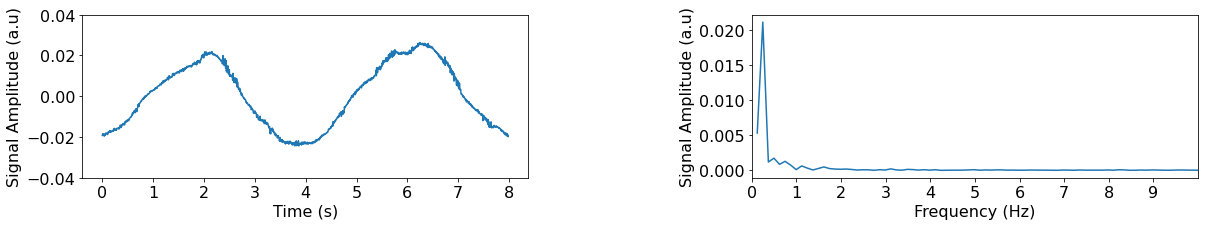

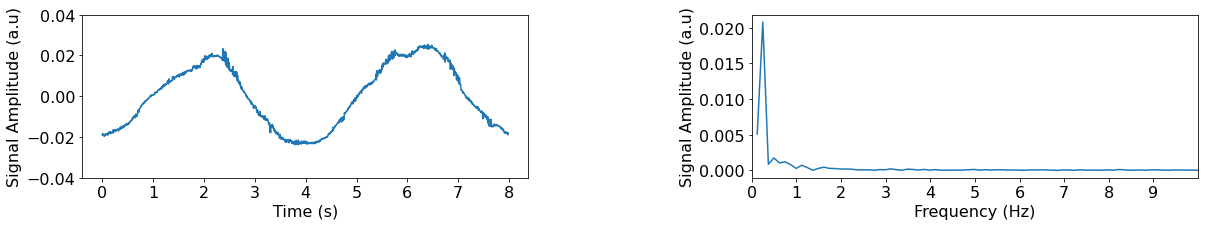

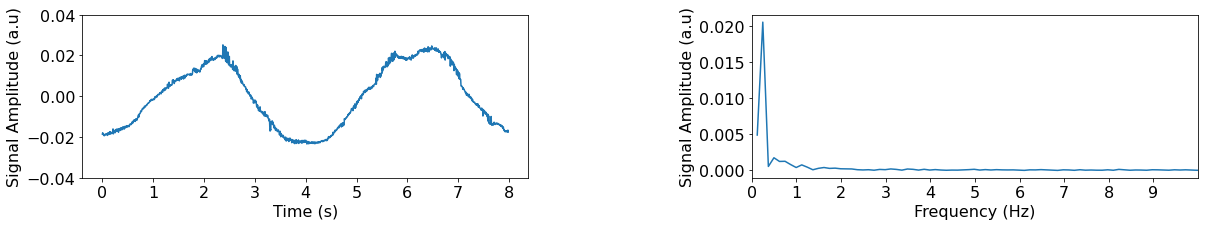

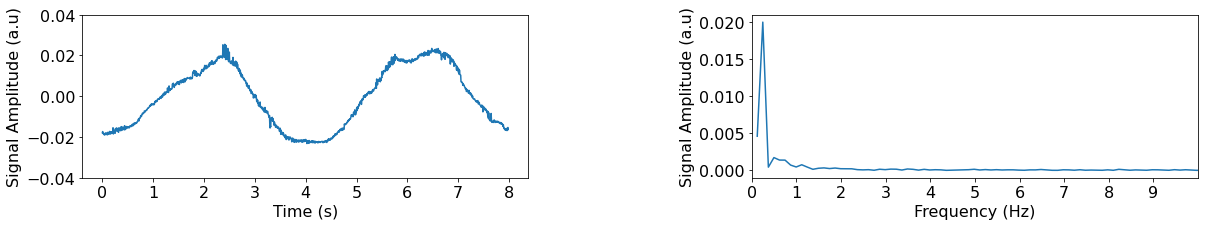

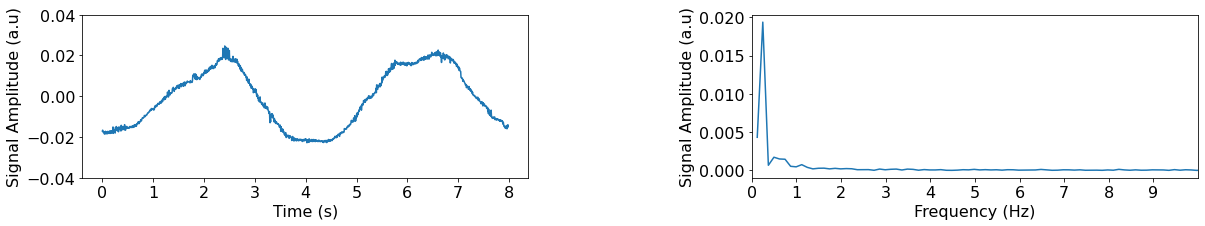

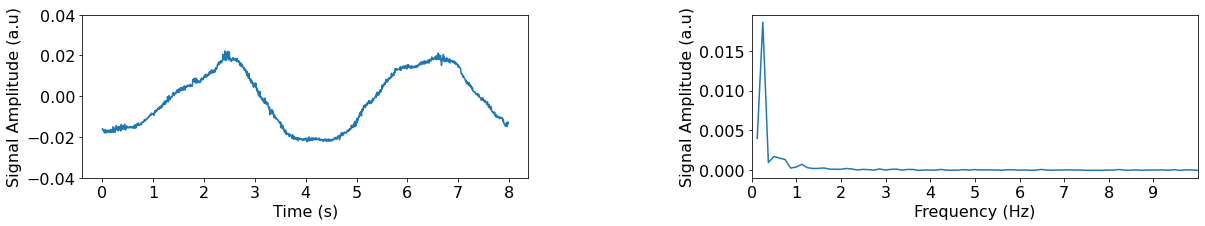

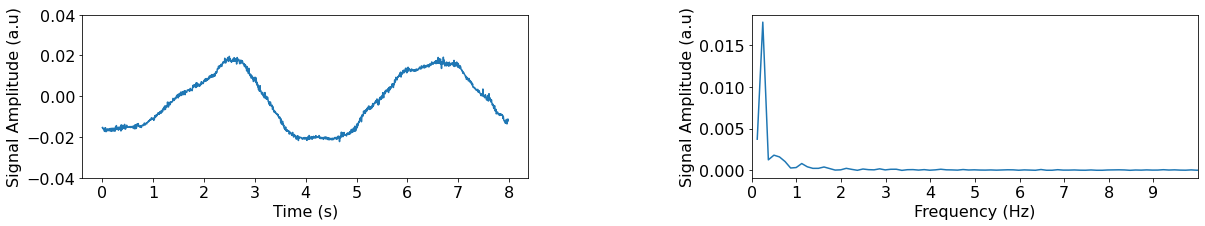

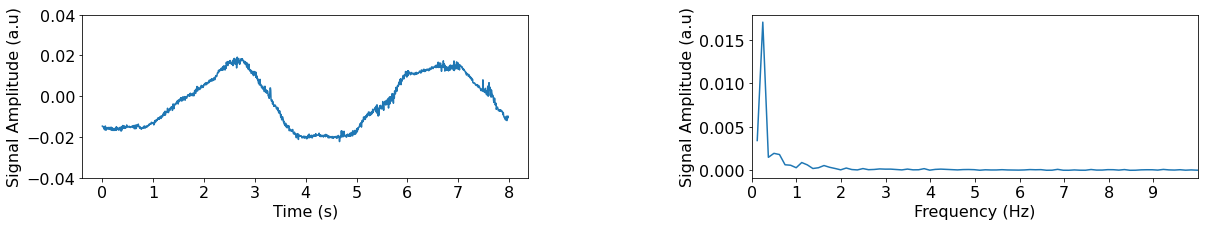

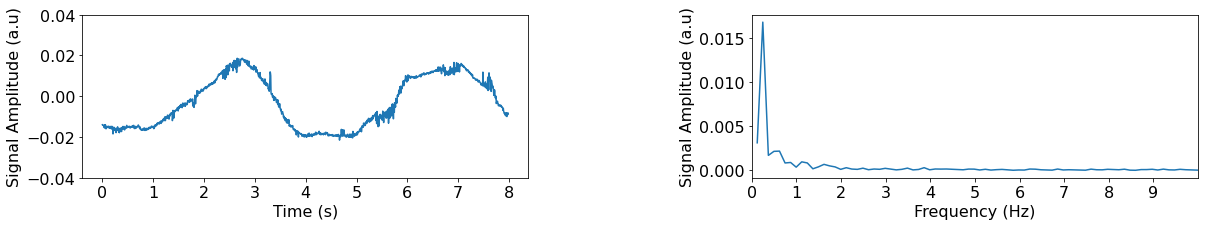

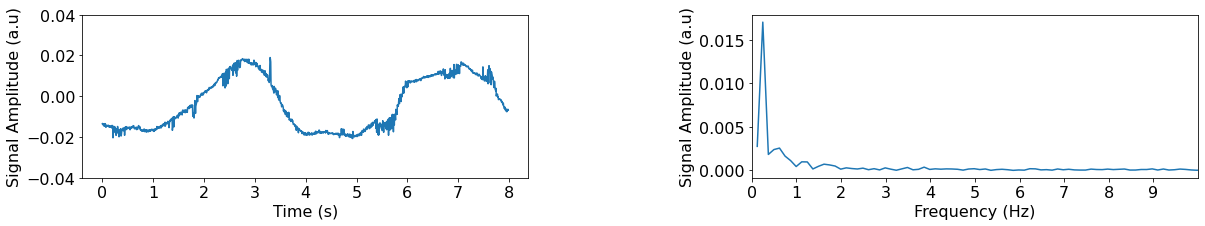

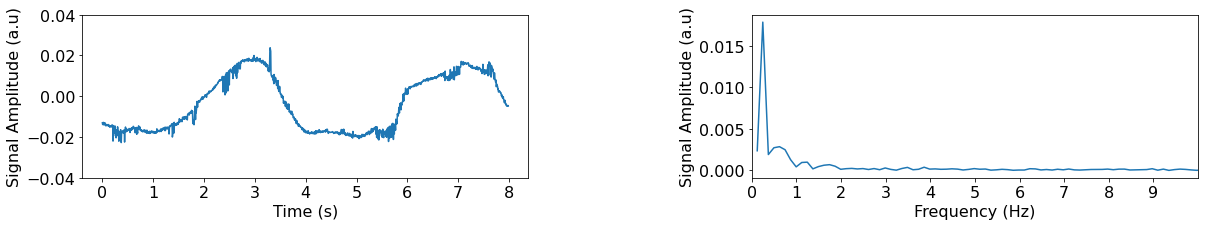

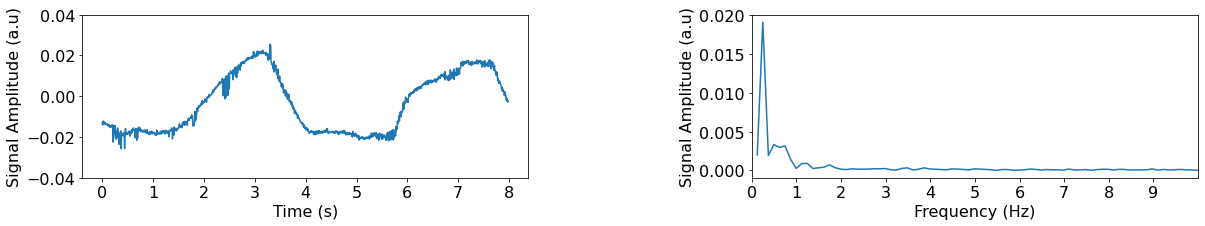

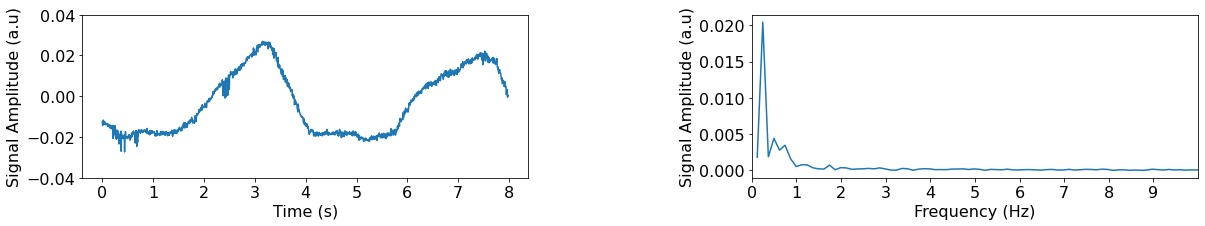

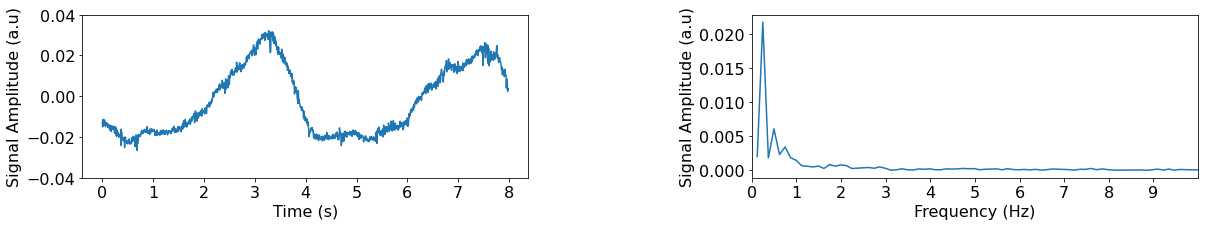

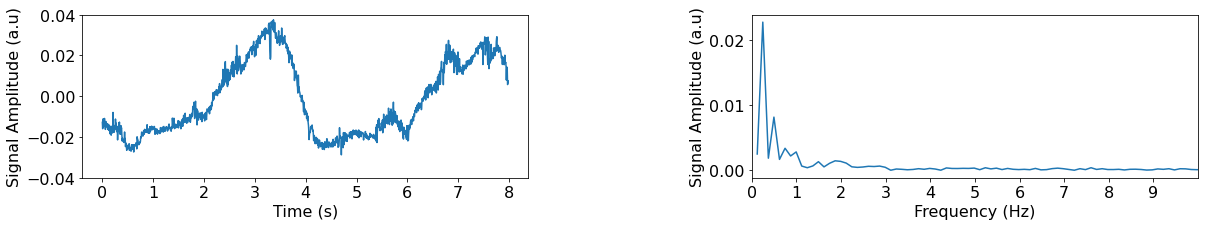

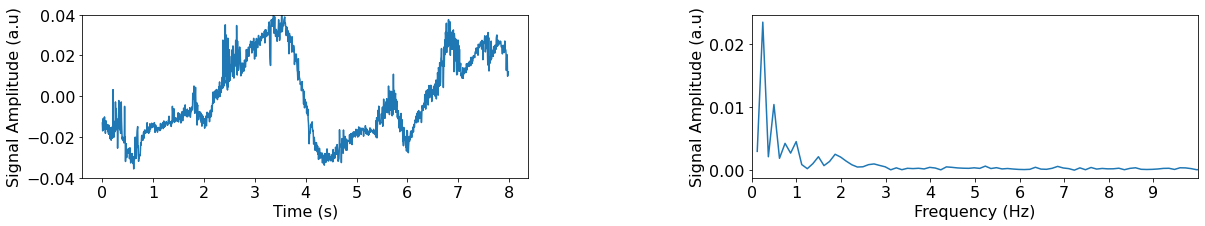

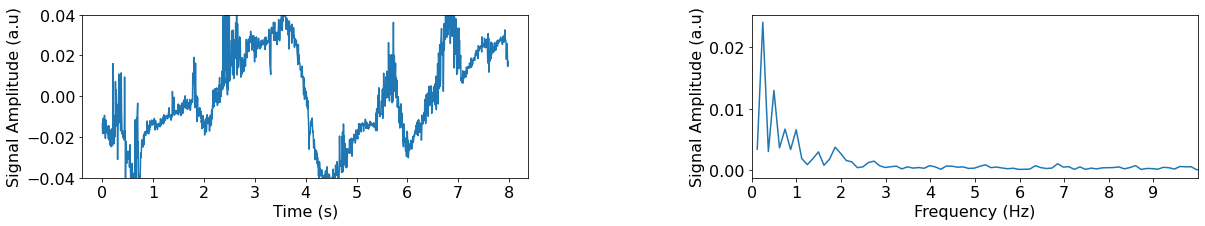

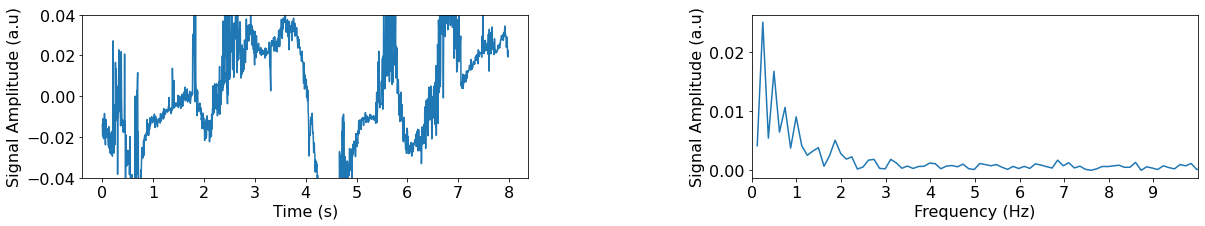

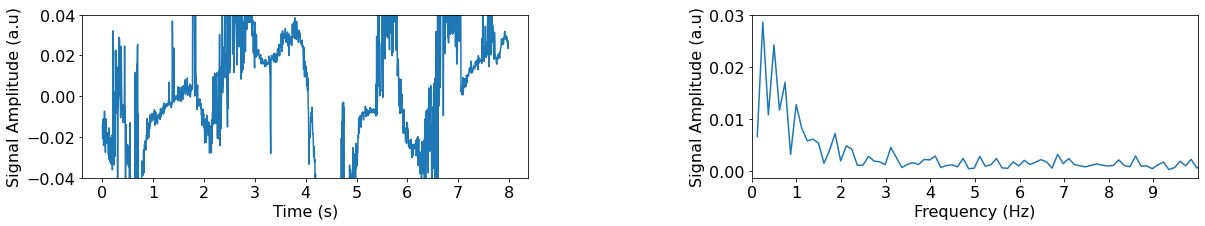

In [13]:
start_frame=worm_pos.index.min()
end_frame=worm_pos.index.max()
start_freq=0 #range of frequencys which should be displayed
end_freq=10 #range of frequencys which should be displayed
fps=167.0 #frames per second
win=5
save=0
for idx,segment in enumerate(Kt_avg):
    x_axis,y_axis=fourier_transform(Kt_avg,fps,segment)
    fourier_plot(x_axis,y_axis,start_frame,end_frame,start_freq,end_freq,win,fps,segment,idx,save)